# E74 · Faded colours: running a fading model backwards, and showing uncertainty when colour *is* the answer

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: (1) the **Rijksmuseum / RCE light-ageing study of Japanese woodblock-print colourants** (Baines et al. 2026, *Journal of Paper Conservation*; Zenodo, CC BY 4.0): reflectance spectra of 19 Edo-period colourants and mixtures printed in 1999 by the Museum of Fine Arts, Boston, faded in 2024 in a **microfading tester** and in a **xenon-arc chamber**, with four Blue Wool references; (2) the **CIE 1964 observer and illuminant D65**; (3) two impressions of **Suzuki Harunobu's *Descending Geese of the Koto Bridges*** (c. 1766, Art Institute of Chicago, CC0) |
| **You will learn** | Turning spectra into colours (CIE observer, CIELAB, **CIEDE2000**) and back to screen pixels · the **Kubelka-Munk** model of a dye on paper, and why fading is *linear* in K/S but not in reflectance · checking a physical assumption (one chromophore that just gets weaker) by the **rank of a matrix** · a hierarchical **stretched-exponential** fading model rendered through the observer and fitted to colour · a failure and its fix: dyes that **brown** as they fade · **transfer between instruments**: what a short, intense microfading test says about a long, gentle exposure, and why one conversion factor does not fit all dyes · predicting **mixtures** from their components as a model check · running the model **backwards**: which colourants, how much, how much light, from a museum photograph · **calibrating photographs** against things that do not fade (paper and carbon ink) · a **marginalised discrete recipe** in PyMC, and a **grid posterior** where the parameter space is small but multimodal · **"cut" inference**: using one model's posterior as another's prior · **uncertainty displays when colour is the estimate**: split swatches, hypothetical-outcome restorations (static and animated), trajectory tubes, a visibility (ΔE00) map, recipe probabilities drawn without colour · a museum decision: **how long can this be displayed?**, plug-in vs risk-based |

## The setting

Japanese prints of the 1760s were printed with plant dyes that are famous for fading. The blue from
**dayflower** (*aigami*, from *Commelina communis*) and the pink from **safflower** (*beni*) can
vanish after months of daylight, and the greens that were mixed from dayflower and a yellow turn
yellow when the blue goes. Many prints of this period survive in colours their makers never saw.

Two questions follow, one looking back and one looking forward:

1. **What did a print look like when it was new?** Looking at a faded print, which colourants are
   there, how much light has it seen, and what colour was each area originally - *and how sure can
   we be?*
2. **How long can it be shown?** A museum lights a print at 50 lux. After how many months will a
   visitor-noticeable change (ΔE00 = 1, a "just noticeable difference") have happened?

Both need a model of **how colour changes with light dose**, fitted to measured fading, with honest
uncertainty. And the first raises a visualisation problem that most uncertainty displays cannot
handle: the thing being estimated *is a colour*, so colour cannot also be used to show the
uncertainty (no "red means uncertain" here).

| part | question | tool |
|---|---|---|
| A | What does fading look like, instrument by instrument? | spectra to CIELAB, fading strips, ΔE00 against Blue Wool |
| B | Can one physical model describe all of it? | Kubelka-Munk, rank check, hierarchical stretched exponential; browning as the failure and its fix |
| C | Does a microfading test predict a long exposure? | a per-dye transfer factor, pooled; what a new dye's test would tell you |
| D | Do mixtures fade like their parts? | prediction without refitting, as a check |
| E | What did Harunobu's print look like? | photographic calibration, a two-impression model, recipe and dose, a grid posterior per colour area |
| F | How do you *show* uncertainty in a colour? | split swatches, restorations as hypothetical outcomes, trajectory tubes, a visibility map, recipe probabilities |
| G | How long can a print be displayed? | time to a just-noticeable change, plug-in vs risk-based |

In [1]:
import io
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import xarray as xr
from IPython.display import HTML, Image, display
from matplotlib import animation
from scipy import ndimage
from scipy.cluster.vq import kmeans2
from scipy.optimize import nnls
from scipy.stats import spearmanr

from pymc_challenges import data

RANDOM_SEED = 74
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 20)


def show_jpeg(fig, quality=85):
    """Photographs compress badly as PNG: show figures of prints as JPEG (a fifth of the size)."""
    buf = io.BytesIO()
    fig.savefig(buf, format="jpeg", dpi=90, pil_kwargs={"quality": quality})
    plt.close(fig)
    display(Image(buf.getvalue()))

## A. From spectra to colours, and what fading looks like

The data are **reflectance spectra**: the fraction of light a sample reflects at each wavelength,
380-730 nm in 10 nm steps, measured again and again as the sample is exposed to light. Exposure is
counted in **million lux hours** (Mlxh): 1 Mlxh is 50 lux (a typical museum limit for works on
paper) for 20,000 hours, roughly eight years of opening hours.

Two instruments faded the same 1999 reconstructions:

* the **microfading tester (MFT)** focuses a 0.6 mm spot of white LED light (2700 K, no UV) at
  about 4 million lux onto the sample and measures the spectrum every 10 seconds: 1.4 Mlxh in 20
  minutes, three spots per sample, averaged;
* the **xenon-arc chamber (XT)** exposes the whole sample to filtered xenon light ("daylight
  through window glass", which includes some UV) at 0.1 million lux, measured after 0.5 to 35 hours:
  up to 3.5 Mlxh.

The MFT also faded four **Blue Wool** references, the dyed wool cloths conservators use as a
common ruler (BW1 fades fastest; each grade is meant to be about twice as durable as the one below).

In [2]:
data.describe("woodblock_fading")
spec = data.load("woodblock_fading")
lab_pub = data.load("woodblock_fading_lab")
cie = data.load("cie1964_d65").set_index("wavelength")

print(spec.groupby("instrument").agg(colourants=("colourant", "nunique"), max_dose=("dose_Mlxh", "max"),
                                      spectra=("dose_Mlxh", lambda d: len(d) // 36)))

woodblock_fading: Reflectance spectra of reconstructions of Edo-period woodblock-print colourants printed on Japanese paper in 1999 by the Museum of Fine Arts, Boston, faded in 2024 by a microfading tester (instrument MFT: 2700 K LED spot, ~4.2 Mlx, no UV; three spots averaged) and in a xenon-arc chamber (XT: daylight-through-glass filter, 0.1 Mlx). One row per (instrument, colourant, dose, wavelength): dose_Mlxh (visible exposure, million lux hours), wavelength (380-730 nm, 10 nm; MFT averaged over +-4 nm), reflectance (0-1), refl_sd (MFT spot sd). Colourants: dayflower, safflower, turmeric, sappanwood, cochineal, yellowwood, orpiment, indigo, Prussian blue, vermilion, red lead, iron oxide, ochre, lead white, mica, brass powder, three mixtures (safflower+dayflower, indigo+orpiment, turmeric+orpiment), the bare paper, and (MFT only) Blue Wool references BW1-BW4.
  source: Baines, Brokerhof, Christoforou, Jansen, van Leeuwen, Patin & Sauvage (2026), Balancing access and preservation: in

### Colour science in a few lines

A colour is what an observer sees when a light source illuminates the sample. With the CIE
colour-matching functions $\bar x, \bar y, \bar z$ (the 1964 "10-degree" observer, as in the study)
and illuminant D65 (daylight) with power $S(\lambda)$, the tristimulus values of a sample with
reflectance $R(\lambda)$ are sums over wavelength, normalised so that a perfect white has
$X = Y = Z = 1$:

$$X = \frac{\sum_\lambda R(\lambda) S(\lambda) \bar x(\lambda)}{\sum_\lambda S(\lambda)\bar x(\lambda)}, \quad
\text{and the same for } Y, Z.$$

CIELAB turns $XYZ$ into lightness $L^*$ (0 black to 100 white), $a^*$ (green to red) and $b^*$
(blue to yellow) with a cube root that roughly equalises perceptual steps. The colour difference
people perceive is best measured by **CIEDE2000** (ΔE00), a corrected distance in CIELAB; ΔE00
around 1 is a just-noticeable difference side by side. All of it is a *linear map followed by a
fixed nonlinearity*, so it can live inside a PyMC model.

The first check: do our colours agree with the ones the authors computed from the same spectra?

In [3]:
WL = np.arange(380, 731, 10)
W_OBS = cie.loc[WL, ["xbar", "ybar", "zbar"]].to_numpy() * cie.loc[WL, "d65"].to_numpy()[:, None]
W_OBS = W_OBS / W_OBS.sum(0)        # reflectance (.., 36) @ W_OBS -> XYZ relative to white
D65_WHITE_2DEG = np.array([0.95047, 1.0, 1.08883])
M_SRGB = np.array([[0.4124, 0.3576, 0.1805], [0.2126, 0.7152, 0.0722], [0.0193, 0.1192, 0.9505]])


def ks(R):
    """Kubelka-Munk: reflectance of an opaque layer -> absorption/scattering ratio K/S."""
    return (1 - R) ** 2 / (2 * R)


def km_reflectance(K):
    """Inverse Kubelka-Munk: K/S -> reflectance (works on NumPy arrays and PyTensor tensors)."""
    return 1 + K - (K**2 + 2 * K) ** 0.5


def xyz_to_lab(XYZ):
    d = 6 / 29
    f = np.where(XYZ > d**3, np.cbrt(np.maximum(XYZ, 1e-12)), XYZ / (3 * d**2) + 4 / 29)
    return np.stack([116 * f[..., 1] - 16, 500 * (f[..., 0] - f[..., 1]), 200 * (f[..., 1] - f[..., 2])], -1)


def spectra_to_lab(R):
    return xyz_to_lab(R @ W_OBS)


def lab_pt(R):
    """The same observer + CIELAB inside a PyTensor graph."""
    d = 6 / 29
    XYZ = pt.dot(R, W_OBS)
    f = pt.switch(XYZ > d**3, pt.maximum(XYZ, 1e-6) ** (1 / 3), XYZ / (3 * d**2) + 4 / 29)
    return pt.stack([116 * f[..., 1] - 16, 500 * (f[..., 0] - f[..., 1]), 200 * (f[..., 1] - f[..., 2])], -1)


def srgb_to_lab(rgb):
    lin = np.where(rgb <= 0.04045, rgb / 12.92, ((rgb + 0.055) / 1.055) ** 2.4)
    return xyz_to_lab(lin @ M_SRGB.T / D65_WHITE_2DEG)


def lab_to_srgb(lab):
    d = 6 / 29
    fy = (lab[..., 0] + 16) / 116
    f = np.stack([fy + lab[..., 1] / 500, fy, fy - lab[..., 2] / 200], -1)
    XYZ = np.where(f > d, f**3, 3 * d**2 * (f - 4 / 29)) * D65_WHITE_2DEG
    lin = np.clip(XYZ @ np.linalg.inv(M_SRGB).T, 0, 1)
    return np.where(lin <= 0.0031308, 12.92 * lin, 1.055 * lin ** (1 / 2.4) - 0.055)


def de2000(lab1, lab2):
    """CIEDE2000 colour difference (Sharma, Wu & Dalal 2005), vectorised over leading axes."""
    L1, a1, b1 = np.moveaxis(np.asarray(lab1, float), -1, 0)
    L2, a2, b2 = np.moveaxis(np.asarray(lab2, float), -1, 0)
    Cb = (np.hypot(a1, b1) + np.hypot(a2, b2)) / 2
    G = 0.5 * (1 - np.sqrt(Cb**7 / (Cb**7 + 25.0**7)))
    a1p, a2p = (1 + G) * a1, (1 + G) * a2
    C1p, C2p = np.hypot(a1p, b1), np.hypot(a2p, b2)
    h1p, h2p = np.degrees(np.arctan2(b1, a1p)) % 360, np.degrees(np.arctan2(b2, a2p)) % 360
    zero = C1p * C2p == 0
    dh = h2p - h1p
    dh = np.where(dh > 180, dh - 360, np.where(dh < -180, dh + 360, dh))
    dh = np.where(zero, 0, dh)
    dL, dC = L2 - L1, C2p - C1p
    dH = 2 * np.sqrt(C1p * C2p) * np.sin(np.radians(dh / 2))
    Lb, Cbp = (L1 + L2) / 2, (C1p + C2p) / 2
    hs = h1p + h2p
    hb = np.where(zero, hs, np.where(np.abs(h1p - h2p) <= 180, hs / 2, np.where(hs < 360, (hs + 360) / 2, (hs - 360) / 2)))
    T = (1 - 0.17 * np.cos(np.radians(hb - 30)) + 0.24 * np.cos(np.radians(2 * hb))
         + 0.32 * np.cos(np.radians(3 * hb + 6)) - 0.20 * np.cos(np.radians(4 * hb - 63)))
    Rt = (-np.sin(np.radians(60 * np.exp(-(((hb - 275) / 25) ** 2))))
          * 2 * np.sqrt(Cbp**7 / (Cbp**7 + 25.0**7)))
    Sl = 1 + 0.015 * (Lb - 50) ** 2 / np.sqrt(20 + (Lb - 50) ** 2)
    Sc, Sh = 1 + 0.045 * Cbp, 1 + 0.015 * Cbp * T
    return np.sqrt((dL / Sl) ** 2 + (dC / Sc) ** 2 + (dH / Sh) ** 2 + Rt * (dC / Sc) * (dH / Sh))


# Sharma et al.'s first test pair has ΔE00 = 2.0425
assert abs(de2000([50, 2.6772, -79.7751], [50, 0, -82.7485]) - 2.0425) < 1e-4


def spectra_table(instrument, colourant):
    """dose x wavelength table of reflectance."""
    s = spec[(spec.instrument == instrument) & (spec.colourant == colourant)]
    return s.pivot(index="dose_Mlxh", columns="wavelength", values="reflectance")


check = []
for (inst, col), _ in spec.groupby(["instrument", "colourant"]):
    tab = spectra_table(inst, col)
    ours = spectra_to_lab(tab.to_numpy())
    pub = lab_pub[(lab_pub.instrument == inst) & (lab_pub.colourant == col)]
    nearest = pub.iloc[[np.argmin(np.abs(pub.dose_Mlxh.to_numpy() - d)) for d in tab.index]]
    check.append((inst, np.abs(ours - nearest[["L", "a", "b"]].to_numpy()).max()))
print(pd.DataFrame(check, columns=["instrument", "max |ours - published|"]).groupby("instrument").max().round(2))

            max |ours - published|
instrument                        
MFT                           0.42
XT                            0.02


The xenon-arc colours agree to 0.02 units, the rounding of the published table. The microfading
colours agree to about 0.4: the authors used the full 1 nm spectrum to 780 nm, our file keeps 10 nm
points to 730 nm (to match the xenon data). Far below a noticeable difference.

### Fading strips

The most direct display of the data is a strip of swatches per colourant, left to right in
increasing dose, painted in the colour each spectrum *renders to*. The number at the right is the
ΔE00 between the first and the last swatch.

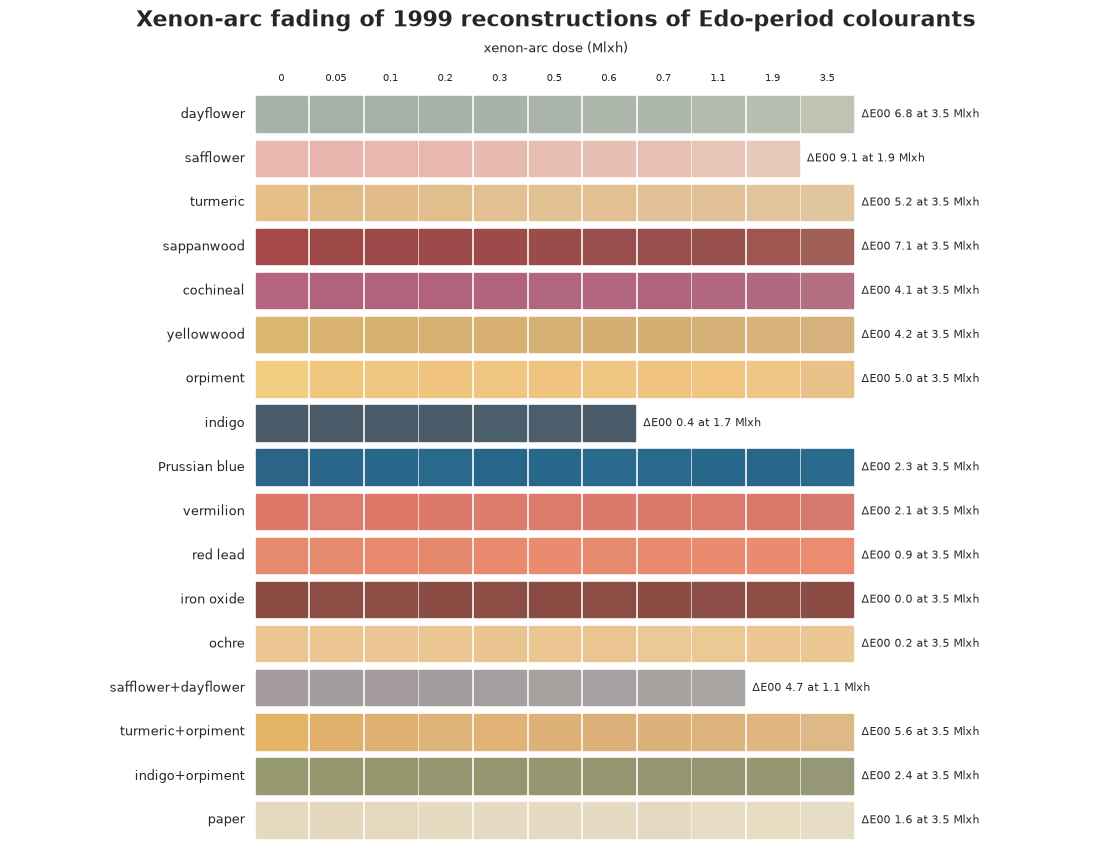

In [4]:
SINGLE = ["dayflower", "safflower", "turmeric", "sappanwood", "cochineal", "yellowwood", "orpiment",
          "indigo", "Prussian blue", "vermilion", "red lead", "iron oxide", "ochre"]
MIXES = {"safflower+dayflower": ("safflower", "dayflower"), "turmeric+orpiment": ("turmeric", "orpiment"),
         "indigo+orpiment": ("indigo", "orpiment")}

fig, ax = plt.subplots(figsize=(11, 8.5))
rows_show = SINGLE + list(MIXES) + ["paper"]
for r, col in enumerate(rows_show):
    tab = spectra_table("XT", col)
    lab = spectra_to_lab(tab.to_numpy())
    rgb = lab_to_srgb(lab)
    for j, d in enumerate(tab.index):
        ax.add_patch(plt.Rectangle((j, -r - 0.9), 0.95, 0.8, color=rgb[j]))
    ax.text(-0.2, -r - 0.5, col, ha="right", va="center", fontsize=9)
    ax.text(len(tab) + 0.1, -r - 0.5, f"ΔE00 {de2000(lab[0], lab[-1]):.1f} at {tab.index[-1]:.1f} Mlxh",
            va="center", fontsize=8)
doses_xt = spectra_table("XT", "dayflower").index
for j, d in enumerate(doses_xt):
    ax.text(j + 0.47, 0.25, f"{d:g}", ha="center", fontsize=7)
ax.text(len(doses_xt) / 2, 0.9, "xenon-arc dose (Mlxh)", ha="center", fontsize=9)
ax.set_xlim(-4.5, len(doses_xt) + 4.5)
ax.set_ylim(-len(rows_show) - 0.2, 1.3)
ax.axis("off")
ax.set_title("Xenon-arc fading of 1999 reconstructions of Edo-period colourants");

The plant dyes behave very differently from the minerals. **Safflower** pink is nearly gone after
1.9 Mlxh; **dayflower** was already a pale grey-green before the test (it faded during the 25 years
since 1999 - "0 Mlxh" here is *not* a fresh print, a point that will matter); **turmeric** and
**yellowwood** lose their yellow; **sappanwood** and **cochineal** reds go brownish rather than
simply paler. Indigo, iron oxide, ochre and red lead barely move. The yellow mixed from turmeric
and orpiment (a mineral yellow) fades much like turmeric alone; the green of indigo and
orpiment changes by less than half as much.

### The Blue Wool ruler

Conservators describe light sensitivity by comparison with Blue Wool: "this dye fades like BW2".
The microfading tester faded the four references alongside the dyes, so every dye can be placed on
that ruler.

ΔE00 of the Blue Wools at 1.4 Mlxh: {'BW1': 2.88, 'BW2': 0.89, 'BW3': 0.32, 'BW4': 0.42}
          colourant  ΔE00 at 1.4 Mlxh (MFT) change compared with Blue Wool
          dayflower                    1.06            between BW1 and BW2
          safflower                    1.40            between BW1 and BW2
           turmeric                    1.28            between BW1 and BW2
         sappanwood                    0.52            BW2 or more durable
          cochineal                    0.37            BW2 or more durable
         yellowwood                    1.08            between BW1 and BW2
           orpiment                    4.67        more sensitive than BW1
             indigo                    0.27            BW2 or more durable
      Prussian blue                    1.25            between BW1 and BW2
          vermilion                    1.12            between BW1 and BW2
           red lead                    0.27            BW2 or more durable
         ir

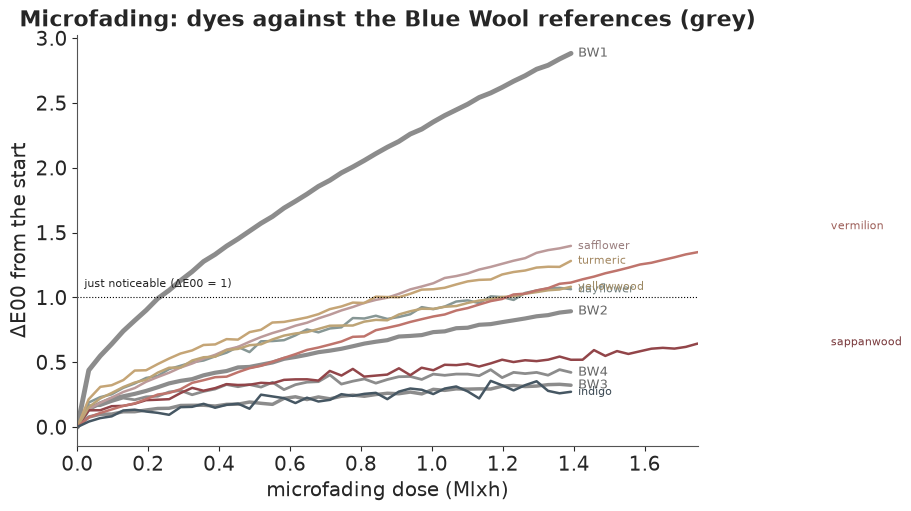

In [5]:
def de_curve(instrument, colourant):
    tab = spectra_table(instrument, colourant)
    lab = spectra_to_lab(tab.to_numpy())
    return tab.index.to_numpy(), de2000(lab[:1], lab)


fig, ax = plt.subplots(figsize=(9, 5))
for bw, lw in zip(["BW1", "BW2", "BW3", "BW4"], [3.5, 3, 2.5, 2]):
    d, e = de_curve("MFT", bw)
    ax.plot(d, e, color="0.55", lw=lw, zorder=1)
    ax.text(d[-1] + 0.02, e[-1], bw, color="0.4", va="center", fontsize=9)
highlight = ["dayflower", "safflower", "turmeric", "sappanwood", "yellowwood", "vermilion", "indigo"]
for col in highlight:
    d, e = de_curve("MFT", col)
    rgb = lab_to_srgb(spectra_to_lab(spectra_table("MFT", col).to_numpy()[0]))
    ax.plot(d, e, color=np.clip(rgb * 0.85, 0, 1), lw=1.8)
    ax.text(d[-1] + 0.02, e[-1], col, fontsize=8, va="center", color=np.clip(rgb * 0.7, 0, 1))
ax.axhline(1, color="k", lw=0.8, ls=":")
ax.text(0.02, 1.08, "just noticeable (ΔE00 = 1)", fontsize=8)
ax.set_xlabel("microfading dose (Mlxh)")
ax.set_ylabel("ΔE00 from the start")
ax.set_xlim(0, 1.75)
ax.set_title("Microfading: dyes against the Blue Wool references (grey)");

rank = []
for col in SINGLE + list(MIXES):
    d, e = de_curve("MFT", col)
    e_end = np.interp(1.4, d, e)
    bw_end = [np.interp(1.4, *de_curve("MFT", bw)) for bw in ["BW1", "BW2", "BW3", "BW4"]]
    grade = ("more sensitive than BW1" if e_end > bw_end[0] else
             "between BW1 and BW2" if e_end > bw_end[1] else "BW2 or more durable")
    rank.append((col, round(float(e_end), 2), grade))
bw_end = {bw: round(float(np.interp(1.4, *de_curve("MFT", bw))), 2) for bw in ["BW1", "BW2", "BW3", "BW4"]}
print("ΔE00 of the Blue Wools at 1.4 Mlxh:", bw_end)
print(pd.DataFrame(rank, columns=["colourant", "ΔE00 at 1.4 Mlxh (MFT)", "change compared with Blue Wool"]).to_string(index=False))

(BW3 and BW4 hardly move in 1.4 Mlxh and their order is within noise, so the ruler is only
resolved at its sensitive end.) Under microfading, most plant dyes change by 1-1.5 ΔE00 in 1.4 Mlxh:
between BW1 and BW2, the "high sensitivity" class. Orpiment is the exception, changing by almost 5,
more than BW1: it *darkens*. Now compare the xenon strips above: at a similar dose (1.1-1.9 Mlxh)
safflower changed by about 8 and dayflower, turmeric and sappanwood by 3-5. **The two instruments
disagree by a large factor.** Part C measures how large.

## B. One physical model for all of it

### Kubelka-Munk: why fading is linear in K/S

A dyed sheet of paper both absorbs (coefficient $K$) and scatters ($S$) light. For a thick,
opaque layer the **Kubelka-Munk** theory gives the reflectance as a function of $K/S$ alone,

$$\frac{K}{S}(\lambda) = \frac{(1 - R(\lambda))^2}{2R(\lambda)}, \qquad
R = 1 + \frac KS - \sqrt{\left(\frac KS\right)^2 + 2\frac KS},$$

and, crucially, $K/S$ **adds up** over the components of the layer: paper plus dye, each dye in
proportion to its amount. So if light destroys a fraction of the dye molecules and leaves
everything else alone, the spectrum at dose $H$ is

$$\frac KS(\lambda, H) = \underbrace{\frac KS_{\text{paper}}(\lambda, H)}_{\text{measured}}
+ q(H)\,\varepsilon(\lambda),\qquad q(0) = 1,$$

where $\varepsilon(\lambda)$ is the dye's own absorption spectrum and $q(H)$ is **the fraction of
dye remaining**. In reflectance or in colour the change is curved and colour-dependent; in K/S it is
one number, $q$, times a fixed shape.

That is testable before any model: stack the *changes* in K/S over doses into a matrix
(dose x wavelength). If one chromophore just gets weaker, the matrix has **rank one**, and its
direction is the dye's own spectrum $\varepsilon$.

In [6]:
paper_xt = spectra_table("XT", "paper")
rank_rows = []
for col in SINGLE + list(MIXES):
    K = ks(spectra_table("XT", col).to_numpy())
    dK = K[1:] - K[0]
    sv = np.linalg.svd(dK, compute_uv=False)
    eps0 = K[0] - ks(paper_xt.to_numpy()[0])
    v1 = np.linalg.svd(dK, full_matrices=False)[2][0]
    rank_rows.append((col, round(sv[0] ** 2 / (sv**2).sum(), 3), round(abs(v1 @ eps0) / np.linalg.norm(eps0), 2)))
rank_tab = pd.DataFrame(rank_rows, columns=["colourant", "share of change in rank 1", "|cos(change, dye spectrum)|"])
print(rank_tab.to_string(index=False))

          colourant  share of change in rank 1  |cos(change, dye spectrum)|
          dayflower                      0.995                         0.99
          safflower                      0.990                         0.99
           turmeric                      0.997                         0.99
         sappanwood                      0.927                         0.85
          cochineal                      0.809                         0.89
         yellowwood                      0.828                         0.78
           orpiment                      0.784                         0.67
             indigo                      0.984                         1.00
      Prussian blue                      0.624                         0.70
          vermilion                      0.988                         0.99
           red lead                      0.829                         0.85
         iron oxide                      0.951                         1.00
            

For **dayflower, safflower, turmeric** and the turmeric-orpiment yellow, over 99% of the change is
one direction, and that direction is the dye's own spectrum (cosine 0.98-0.99): textbook
"one chromophore disappearing". **Sappanwood, cochineal, yellowwood, orpiment** and **Prussian
blue** are less clean: something *else* changes as they fade (for the organic reds and yellows,
brownish degradation products are the usual suspect). The stable minerals have so little change that
the rank of their "change" is mostly noise. A model that assumes pure loss will fit the first group
and struggle with the second. We fit it anyway, look at where it fails, and then fix it.

### The fading curve

For $q(H)$ use a **stretched exponential**,

$$q(H) = \exp\!\big(-(kH)^\beta\big),$$

with rate $k$ (per Mlxh) and shape $\beta$. $\beta = 1$ is first-order kinetics (each molecule
equally likely to be destroyed); $\beta < 1$ is what a heterogeneous population gives (exposed
molecules on the surface go first, protected ones later) and is typical of dyes on paper.

The model is **hierarchical** over the 13 single colourants (log rates and log shapes are drawn
from common distributions, so a dye with little information borrows from the others), and it is
fitted to **colour**: each spectrum predicted by the K/S model is rendered through the observer to
CIELAB and compared with the measured colour by a Student-t with its own scale for each colourant
and instrument. Colour rather than 36 correlated reflectances keeps the likelihood from pretending
to have 36 independent measurements per spectrum, and puts the error in units people perceive.

Both instruments go into the same model. Their doses are *not* assumed equivalent: the rate under
microfading is $k\,\tau$, with a **transfer factor** $\tau$ per colourant, also pooled. Part C is
about $\tau$.

The paper term is the measured paper sample at the same dose (paper also changes under light), and
$\varepsilon$ is taken from each sample's first spectrum on each instrument (the two instruments
measure different spots and read slightly differently).

In [7]:
def build_rows(instruments=("XT", "MFT"), n_mft=12):
    rows = []
    for inst in instruments:
        paper = spectra_table(inst, "paper")
        for col in SINGLE:
            tab = spectra_table(inst, col)
            d = tab.index.to_numpy()
            if inst == "MFT":  # 44 spectra per dye: 12 evenly spaced ones are plenty, and weigh less
                keep = np.unique(np.linspace(0, len(d) - 1, n_mft).round().astype(int))
                tab, d = tab.iloc[keep], d[keep]
            Kp = np.stack([np.interp(d, paper.index, ks(paper[w].to_numpy())) for w in WL], 1)
            eps = ks(tab.to_numpy()[0]) - Kp[0]
            for i, dose in enumerate(d):
                rows.append(dict(inst=inst, col=col, dose=dose, Kp=Kp[i], eps=eps,
                                 lab=spectra_to_lab(tab.to_numpy()[i])))
    return pd.DataFrame(rows)


fade = build_rows()
fade["group"] = fade.inst + ": " + fade.col
groups = list(dict.fromkeys(fade.group))
col_idx = fade.col.map({c: i for i, c in enumerate(SINGLE)}).to_numpy()
grp_idx = fade.group.map({g: i for i, g in enumerate(groups)}).to_numpy()
is_mft = (fade.inst == "MFT").to_numpy().astype(float)
Kp_rows, eps_rows = np.stack(fade.Kp), np.stack(fade.eps)
lab_obs = np.stack(fade.lab)
print(fade.groupby("inst").size().rename("spectra"))


inst_idx = is_mft.astype(int)          # 0 = xenon arc, 1 = microfading


def fading_model(products: bool):
    coords = {"col": SINGLE, "group": groups, "obs": np.arange(len(fade)), "lab": ["L", "a", "b"],
              "inst": ["XT", "MFT"]}
    with pm.Model(coords=coords) as m:
        mu_k = pm.Normal("mu_logk", -2, 1.5)
        sd_k = pm.HalfNormal("sd_logk", 2)
        logk = pm.Deterministic("logk", mu_k + sd_k * pm.Normal("z_logk", 0, 1, dims="col"), dims="col")
        mu_b = pm.Normal("mu_logbeta", 0, 0.5)
        sd_b = pm.HalfNormal("sd_logbeta", 0.3)
        logbeta = pm.Deterministic("logbeta", mu_b + sd_b * pm.Normal("z_logbeta", 0, 1, dims="col"), dims="col")
        mu_t = pm.Normal("mu_logtau", 0, 1.5)
        sd_t = pm.HalfNormal("sd_logtau", 1)
        logtau = pm.Deterministic("logtau", mu_t + sd_t * pm.Normal("z_logtau", 0, 1, dims="col"), dims="col")
        rate = pt.exp(logk[col_idx] + is_mft * logtau[col_idx])
        q = pt.exp(-((rate * fade.dose.to_numpy() + 1e-12) ** pt.exp(logbeta[col_idx])))
        K = Kp_rows + q[:, None] * eps_rows
        if products:
            rho = pm.HalfNormal("rho", 0.5, dims=("inst", "col"))
            ell = pm.LogNormal("ell", np.log(60), 0.5, dims=("inst", "col"))
            shape = pt.exp(-(WL[None, :] - 380) / ell[inst_idx, col_idx][:, None])
            K = K + (rho[inst_idx, col_idx] * (1 - q))[:, None] * shape
        sigma = pm.HalfNormal("sigma", 1, dims="group")
        pm.StudentT("lab_obs", nu=4, mu=lab_pt(km_reflectance(K)), sigma=sigma[grp_idx][:, None],
                    observed=lab_obs, dims=("obs", "lab"))
    return m

inst
MFT    156
XT     138
Name: spectra, dtype: int64


**Prior predictive check.** Before fitting, what do these priors say about fading? Draw rates and
shapes from the prior and look at the fraction of dye left after 1 and after 10 Mlxh (xenon).

In [8]:
with fading_model(products=False):
    prior = pm.sample_prior_predictive(1000, random_seed=RANDOM_SEED)
pk = np.exp(prior.prior["logk"].values.reshape(-1))
pb = np.exp(prior.prior["logbeta"].values.reshape(-1))
q_prior = {H: np.exp(-((pk * H) ** pb)) for H in (1, 10)}
print(pd.DataFrame({f"q after {H} Mlxh": np.quantile(v, [0.05, 0.25, 0.5, 0.75, 0.95]) for H, v in q_prior.items()},
                   index=["5%", "25%", "50%", "75%", "95%"]).round(3))
print("prior 90% interval of tau:", np.quantile(np.exp(prior.prior["logtau"].values), [0.05, 0.95]).round(3))

     q after 1 Mlxh  q after 10 Mlxh
5%            0.000            0.000
25%           0.535            0.004
50%           0.849            0.286
75%           0.973            0.678
95%           1.000            0.989
prior 90% interval of tau: [ 0.054 18.681]


The prior allows anything from "untouched after 10 Mlxh" to "gone after 1 Mlxh", with most mass in
between: weakly informative on the scale that matters. The transfer factor may be anywhere from about
1/20 to 20.

### First fit: pure loss of dye

In [9]:
t0 = time.time()
with fading_model(products=False) as m_loss:
    idata_loss = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    pm.compute_log_likelihood(idata_loss, progressbar=False)
print(f"sampled in {time.time() - t0:.0f} s; divergences: {int(idata_loss.sample_stats['diverging'].sum())}; "
      f"largest r_hat: {float(az.summary(idata_loss, var_names=['logk', 'logbeta', 'logtau', 'sigma']).r_hat.max()):.2f}")

sampled in 10 s; divergences: 0; largest r_hat: 1.01


The sampler is healthy. Is the model? The fitted scales $\sigma$ are the typical colour error per
colourant and instrument (in CIELAB units): a direct posterior predictive summary.

In [10]:
def sigma_table(idata):
    return idata.posterior["sigma"].median(("chain", "draw")).to_series()


sig_loss = sigma_table(idata_loss)
print(sig_loss.sort_values(ascending=False).head(8).round(2))

group
MFT: orpiment        2.80
XT: sappanwood       2.70
XT: orpiment         2.66
XT: yellowwood       2.38
XT: turmeric         1.64
XT: cochineal        1.46
XT: Prussian blue    0.96
XT: vermilion        0.92
Name: sigma, dtype: float64


The worst fits are the colourants the rank check flagged (orpiment, sappanwood, yellowwood,
cochineal), plus turmeric, with typical errors of 1.5-2.8 CIELAB units, which is visible. The
picture shows *how* they fail: in the $a^*b^*$ plane the measured colours take a direction the
model's paths cannot follow, because losing dye can only move a colour towards the paper's.

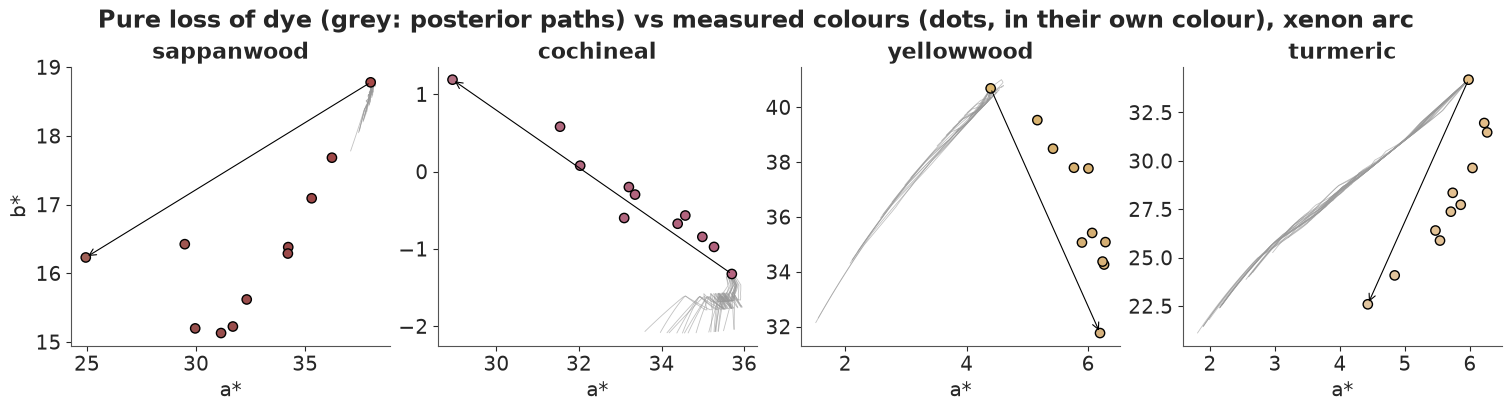

In [11]:
def fitted_path(idata, col, inst, products, n_dose=40, draws=200):
    """Posterior draws of the rendered colour along a dose grid."""
    rows = fade[(fade.col == col) & (fade.inst == inst)]
    H = np.linspace(0, rows.dose.max(), n_dose)
    paper = spectra_table(inst, "paper")
    Kp = np.stack([np.interp(H, paper.index, ks(paper[w].to_numpy())) for w in WL], 1)
    eps = rows.eps.iloc[0]
    post = az.extract(idata, num_samples=draws, random_seed=1)
    c = SINGLE.index(col)
    k = np.exp(post["logk"].values[c] + (inst == "MFT") * post["logtau"].values[c])
    b = np.exp(post["logbeta"].values[c])
    q = np.exp(-((k[:, None] * H[None]) ** b[:, None]))
    K = Kp[None] + q[..., None] * eps
    if products:
        ell_, rho_ = post["ell"].sel(inst=inst).values[c], post["rho"].sel(inst=inst).values[c]
        shape = np.exp(-(WL[None, :] - 380) / ell_[:, None])
        K = K + (rho_[:, None] * (1 - q))[..., None] * shape[:, None, :]
    return H, spectra_to_lab(km_reflectance(K))


fig, axs = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axs, ["sappanwood", "cochineal", "yellowwood", "turmeric"]):
    rows = fade[(fade.col == col) & (fade.inst == "XT")]
    obs = np.stack(rows.lab)
    _, path = fitted_path(idata_loss, col, "XT", products=False)
    for p in path[::10]:
        ax.plot(p[:, 1], p[:, 2], color="0.6", lw=0.6, alpha=0.6)
    ax.scatter(obs[:, 1], obs[:, 2], c=lab_to_srgb(obs), edgecolor="k", s=45, zorder=3)
    ax.annotate("", xy=obs[-1, 1:], xytext=obs[0, 1:], arrowprops=dict(arrowstyle="->", color="k", lw=0.8))
    ax.set_title(col)
    ax.set_xlabel("a*")
axs[0].set_ylabel("b*")
fig.suptitle("Pure loss of dye (grey: posterior paths) vs measured colours (dots, in their own colour), xenon arc");

### The fix: coloured degradation products

Dyes do not vanish into nothing; they break into smaller molecules, and for many natural reds and
yellows those absorb in the blue and violet, which reads as brown or yellow. Add a second
absorber that **grows as the dye is lost**:

$$\frac KS(\lambda, H) = \frac KS_{\text{paper}} + q(H)\,\varepsilon(\lambda)
+ \rho\,(1 - q(H))\, e^{-(\lambda - 380)/\ell},$$

with amount $\rho \ge 0$ and a smooth absorption falling with wavelength over a scale $\ell$ (nm);
$\rho = 0$ recovers the first model. Which products form depends on the light: the xenon chamber's
UV opens reaction paths that the LED's visible light does not. So $\rho$ and $\ell$ are estimated
**separately for each instrument** (a first version that shared them was dominated by the smooth,
precise microfading curves and still missed the direction of the xenon changes).

In [12]:
t0 = time.time()
with fading_model(products=True) as m_fade:
    # 1000 warm-up steps: with nutpie's default 400 the population rate parameters had r_hat ~1.03
    idata_fade = pm.sample(tune=1000, random_seed=RANDOM_SEED, progressbar=False)
    pm.compute_log_likelihood(idata_fade, progressbar=False)
print(f"sampled in {time.time() - t0:.0f} s; divergences: {int(idata_fade.sample_stats['diverging'].sum())}; "
      f"largest r_hat: {float(az.summary(idata_fade, var_names=['logk', 'logbeta', 'logtau', 'rho', 'ell', 'sigma']).r_hat.max()):.2f}")

sig_fade = sigma_table(idata_fade)
print(pd.DataFrame({"pure loss": sig_loss, "with products": sig_fade}).loc[sig_loss.sort_values(ascending=False).index[:8]].round(2))

loo_loss, loo_fade = az.loo(idata_loss), az.loo(idata_fade)
print(az.compare({"pure loss": loo_loss, "with products": loo_fade}, round_to=1)[["elpd", "elpd_diff", "dse", "p"]])
del idata_loss

sampled in 137 s; divergences: 0; largest r_hat: 1.01
                   pure loss  with products
group                                      
MFT: orpiment           2.80           2.42
XT: sappanwood          2.70           1.01
XT: orpiment            2.66           1.79
XT: yellowwood          2.38           0.50
XT: turmeric            1.64           0.62
XT: cochineal           1.46           0.48
XT: Prussian blue       0.96           0.84
XT: vermilion           0.92           0.66


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


                elpd  elpd_diff   dse      p
with products -110.6        0.0   0.0  100.0
pure loss     -811.2     -700.6  38.3   71.5


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


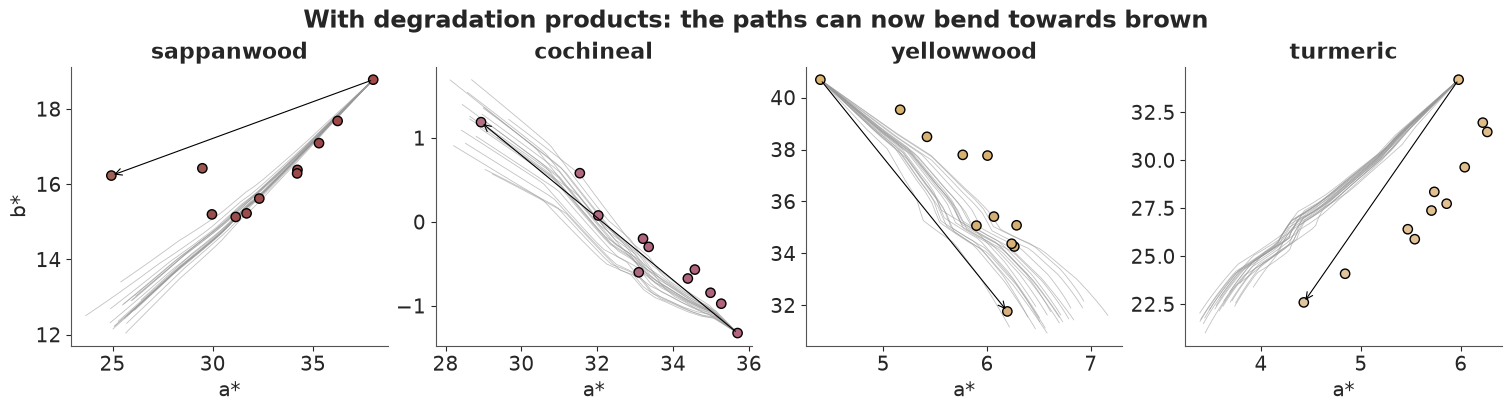

In [13]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axs, ["sappanwood", "cochineal", "yellowwood", "turmeric"]):
    rows = fade[(fade.col == col) & (fade.inst == "XT")]
    obs = np.stack(rows.lab)
    _, path = fitted_path(idata_fade, col, "XT", products=True)
    for p in path[::10]:
        ax.plot(p[:, 1], p[:, 2], color="0.6", lw=0.6, alpha=0.6)
    ax.scatter(obs[:, 1], obs[:, 2], c=lab_to_srgb(obs), edgecolor="k", s=45, zorder=3)
    ax.annotate("", xy=obs[-1, 1:], xytext=obs[0, 1:], arrowprops=dict(arrowstyle="->", color="k", lw=0.8))
    ax.set_title(col)
    ax.set_xlabel("a*")
axs[0].set_ylabel("b*")
fig.suptitle("With degradation products: the paths can now bend towards brown");

The errors of the browning dyes drop by a factor of two to five (yellowwood from 2.4 to 0.5), and
LOO prefers the product model by a margin many times its standard error. (LOO here leaves out one
colour coordinate of one spectrum at a time; the measurements along a fading curve are correlated,
so the margin is flattering, and several Pareto $k$ values above 0.7 say the same; its direction is
not in doubt.) Two misfits remain and are worth
saying out loud: orpiment, an arsenic sulfide that darkens on its own terms rather than bleaching,
is still off by about 2 units; and turmeric's path runs 1-2 units of $a^*$ to one side of the data.

The fitted fading parameters, as rates in the xenon chamber:

In [14]:
post_fade = idata_fade.posterior


def q90(x, dims=("chain", "draw")):
    return x.quantile([0.05, 0.5, 0.95], dim=dims)


k_q = q90(np.exp(post_fade["logk"]))
b_q = q90(np.exp(post_fade["logbeta"]))
half = q90((np.log(2) ** (1 / np.exp(post_fade["logbeta"]))) / np.exp(post_fade["logk"]))
tab_rates = pd.DataFrame({
    "k per Mlxh (median)": k_q.sel(quantile=0.5).values,
    "beta (median)": b_q.sel(quantile=0.5).values,
    "half-life Mlxh 5%": half.sel(quantile=0.05).values,
    "half-life Mlxh 50%": half.sel(quantile=0.5).values,
    "half-life Mlxh 95%": half.sel(quantile=0.95).values,
    "rho xenon": post_fade["rho"].sel(inst="XT").median(("chain", "draw")).values,
    "rho microfading": post_fade["rho"].sel(inst="MFT").median(("chain", "draw")).values,
}, index=SINGLE)
print(tab_rates.sort_values("half-life Mlxh 50%").round(3))

               k per Mlxh (median)  beta (median)  half-life Mlxh 5%  half-life Mlxh 50%  half-life Mlxh 95%  rho xenon  rho microfading
turmeric                     1.166          0.566              0.308               0.448               0.685      0.869            0.552
yellowwood                   0.839          0.596              0.445               0.645               1.030      3.155            1.767
safflower                    0.675          0.723              0.834               0.893               0.966      0.147            0.165
dayflower                    0.274          0.787              2.034               2.287               2.512      0.224            0.057
sappanwood                   0.126          0.548              2.809               4.071               6.754      2.010            1.287
orpiment                     0.056          0.492              3.263               8.378              37.992      1.458            0.898
cochineal                    0.052       

The **half-life** (dose at which half the dye is gone, $(\ln 2)^{1/\beta}/k$) summarises each
curve: turmeric, yellowwood, safflower, dayflower and sappanwood lose half their (remaining) dye
within 0.4-4 xenon Mlxh. Cochineal and orpiment take about ten; the mineral pigments tens to
hundreds, with upper limits in the thousands, which is to say the data only bound them from below.
All shapes are below 1: stretched, heterogeneous fading. The chamber makes more coloured product
than the LED for most dyes (cochineal about three times as much): UV light browns.

## C. Does a microfading test predict a long exposure?

Microfading is attractive because it is fast and practically non-destructive: a museum can test an
object in 20 minutes on a spot smaller than a millimetre. But its light is 40 times more intense
than the xenon chamber's, has no UV, and hits a tiny spot. Is a microfading Mlxh worth a xenon
Mlxh? The model's transfer factor $\tau$ answers: under microfading the dye fades *as if* it had
received $\tau$ times the dose.

pooled median tau: 0.10; spread between dyes (sd of log tau): 1.05; a new colourant's 90% predictive interval: 0.016 - 0.79


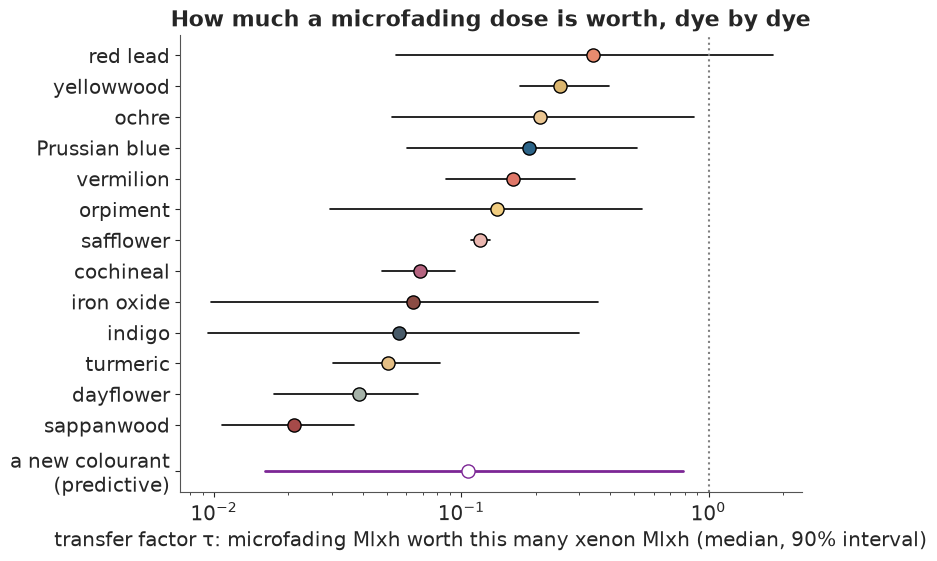

In [15]:
tau = np.exp(post_fade["logtau"])
tau_q = q90(tau)
order = np.argsort(tau_q.sel(quantile=0.5).values)
mu_t = post_fade["mu_logtau"].values.reshape(-1)
sd_t = post_fade["sd_logtau"].values.reshape(-1)
tau_new = np.exp(mu_t + sd_t * rng.standard_normal(mu_t.size))

fig, ax = plt.subplots(figsize=(8, 5.5))
for y, i in enumerate(order):
    lo, md, hi = tau_q.isel(col=i).values
    rgb = lab_to_srgb(spectra_to_lab(spectra_table("XT", SINGLE[i]).to_numpy()[0]))
    ax.plot([lo, hi], [y, y], color="k", lw=1.2)
    ax.scatter(md, y, s=90, color=rgb, edgecolor="k", zorder=3)
lo, md, hi = np.quantile(tau_new, [0.05, 0.5, 0.95])
ax.plot([lo, hi], [-1.5, -1.5], color="C3", lw=2)
ax.scatter(md, -1.5, s=90, color="white", edgecolor="C3", zorder=3)
ax.set_yticks(list(range(len(SINGLE))) + [-1.5])
ax.set_yticklabels([SINGLE[i] for i in order] + ["a new colourant\n(predictive)"])
ax.axvline(1, color="0.5", ls=":")
ax.set_xscale("log")
ax.set_xlabel("transfer factor τ: microfading Mlxh worth this many xenon Mlxh (median, 90% interval)")
ax.set_title("How much a microfading dose is worth, dye by dye");
print(f"pooled median tau: {np.exp(np.median(mu_t)):.2f}; spread between dyes (sd of log tau): "
      f"{np.median(sd_t):.2f}; a new colourant's 90% predictive interval: {lo:.3f} - {hi:.2f}")

For the dyes that actually fade (and therefore carry information), a microfading Mlxh is worth
between about **a fiftieth (sappanwood) and a quarter (yellowwood)** of a xenon Mlxh, and the dyes
differ well beyond their uncertainty: dayflower and sappanwood fade far more slowly under the LED
spot than in the chamber, safflower and yellowwood less so. For the stable minerals the factor is
barely identified: little faded in either instrument. A single conversion factor does not exist, and
the predictive interval for a *new* colourant spans a factor of about fifty.

Why? Some of it is the missing UV (the chamber's filtered xenon light contains some; the LED has
none), some the intensity (photochemistry need not scale with the product intensity x time, the
"reciprocity" assumption), some the tiny spot (heat, oxygen supply). The data cannot separate these,
since every dye saw the same two conditions: all they identify is the product.

**Does microfading at least rank the dyes correctly?** Compare the order of the rates under the two
instruments, draw by draw.

In [16]:
fugitive = ["dayflower", "safflower", "turmeric", "sappanwood", "cochineal", "yellowwood", "orpiment"]
sel = [SINGLE.index(c) for c in fugitive]
lk = post_fade["logk"].values.reshape(-1, len(SINGLE))[:, sel]
lt = post_fade["logtau"].values.reshape(-1, len(SINGLE))[:, sel]
rho_s = np.array([spearmanr(lk[i], lk[i] + lt[i]).statistic for i in range(0, len(lk), 4)])
print(f"rank correlation between xenon and microfading rates of the {len(fugitive)} fading dyes: "
      f"median {np.median(rho_s):.2f}, 90% interval {np.quantile(rho_s, 0.05):.2f} - {np.quantile(rho_s, 0.95):.2f}")

rank correlation between xenon and microfading rates of the 7 fading dyes: median 0.79, 90% interval 0.64 - 0.93


Roughly yes, with reordering among neighbours: microfading tells you *which* colourants are
sensitive, not *how fast* they fade under other light. The practical consequence for Part G: a
display-time calculation needs an assumption about which instrument the gallery lighting
resembles, and the answer depends on it.

## D. Do mixtures fade like their parts?

Greens and purples were printed as mixtures (or overprints) of two colourants. Kubelka-Munk says
the K/S of a mixture is the sum of its parts, so a mixture's fading should be **predictable from
the single-colourant fits, with no new fitting**: find how much of each component the mixture
contains from its first spectrum (non-negative least squares in K/S), then fade each component by
its own posterior. Any mismatch is a failure of the assumption that components fade independently.

safflower+dayflower    largest ΔE00 between predicted (median) and measured colour: 2.5
turmeric+orpiment      largest ΔE00 between predicted (median) and measured colour: 3.2
indigo+orpiment        largest ΔE00 between predicted (median) and measured colour: 1.1


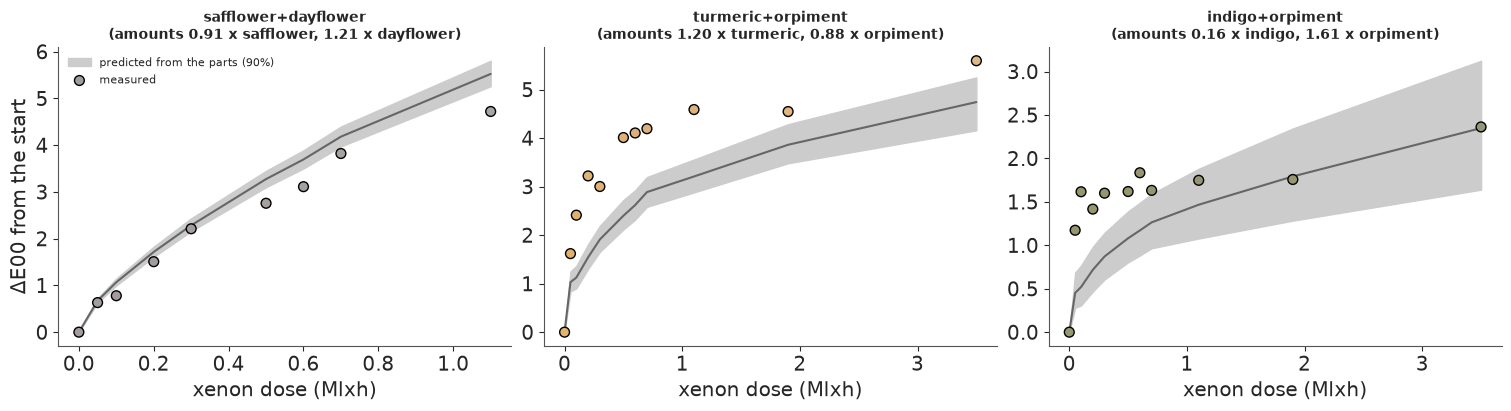

In [17]:
def mixture_prediction(mix, parts, draws=300):
    tab = spectra_table("XT", mix)
    H = tab.index.to_numpy()
    Kp = np.stack([np.interp(H, paper_xt.index, ks(paper_xt[w].to_numpy())) for w in WL], 1)
    epss = [ks(spectra_table("XT", p).to_numpy()[0]) - ks(paper_xt.to_numpy()[0]) for p in parts]
    amounts, _ = nnls(np.stack(epss, 1), ks(tab.to_numpy()[0]) - Kp[0])
    post = az.extract(idata_fade, num_samples=draws, random_seed=2)
    K = np.broadcast_to(Kp, (draws, *Kp.shape)).copy()
    for a, p, e in zip(amounts, parts, epss):
        c = SINGLE.index(p)
        k, b = np.exp(post["logk"].values[c]), np.exp(post["logbeta"].values[c])
        q = np.exp(-((k[:, None] * H[None]) ** b[:, None]))
        shape = np.exp(-(WL[None, :] - 380) / post["ell"].sel(inst="XT").values[c][:, None])
        rho_ = post["rho"].sel(inst="XT").values[c]
        K += a * (q[..., None] * e + (rho_[:, None] * (1 - q))[..., None] * shape[:, None, :])
    pred = spectra_to_lab(km_reflectance(K))
    obs = spectra_to_lab(tab.to_numpy())
    return H, amounts, de2000(pred[:, :1], pred), de2000(obs[:1], obs), pred, obs


fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, (mix, parts) in zip(axs, MIXES.items()):
    H, amounts, de_pred, de_obs, pred, obs = mixture_prediction(mix, parts)
    lo, md, hi = np.quantile(de_pred, [0.05, 0.5, 0.95], axis=0)
    ax.fill_between(H, lo, hi, color="0.8", label="predicted from the parts (90%)")
    ax.plot(H, md, color="0.4")
    ax.scatter(H, de_obs, c=lab_to_srgb(obs), edgecolor="k", s=50, zorder=3, label="measured")
    ax.set_title(f"{mix}\n(amounts {amounts[0]:.2f} x {parts[0]}, {amounts[1]:.2f} x {parts[1]})", fontsize=10)
    ax.set_xlabel("xenon dose (Mlxh)")
    gap = de2000(np.median(pred, 0), obs)
    print(f"{mix:22s} largest ΔE00 between predicted (median) and measured colour: {gap.max():.1f}")
axs[0].set_ylabel("ΔE00 from the start")
axs[0].legend(fontsize=8);

Without fitting anything to the mixtures, the prediction gets the size of the change right to
within 1-3 ΔE00, but not all of its timing. The purple (safflower over dayflower) is tracked closely
to 0.3 Mlxh and then over-predicted by about 1 ΔE00. Both orpiment mixtures change **faster at first**
than their parts predict: most of their change happens in the first 0.1-0.5 Mlxh, a jump that
neither single colourant shows, and then the prediction catches up. So components do not fade
quite independently when orpiment is involved. For the dayflower greens of the print below
(dayflower with an organic yellow) the purple's behaviour is the better guide, and it supports
independence as a working assumption.

## E. What did Harunobu's print look like?

### Two impressions of the same design

The Art Institute of Chicago owns two impressions of *Descending Geese of the Koto Bridges*
(*Kotoji no rakugan*), from Suzuki Harunobu's series *Eight Views of the Parlor*, c. 1766. The same
blocks printed both. Two and a half centuries later they look different: the leaves at top left are
green in one and yellow in the other, the paper is cream in one and pink-beige in the other. Some of
that is fading, some the paper, some the photography, and some possibly a different choice of
colours at the printer's (the second impression also carries the artist's seal, which the first
lacks).

In [18]:
data.describe("harunobu_impressions")
prints = np.load(data.path("harunobu_impressions"))
imgs = prints["images"].astype(float) / 255
print(prints["aic_id"], prints["design"])
IMP = ["AIC 20814", "AIC 88966"]

# The two photographs differ in scale and framing: register the second onto the first with a scale
# and a shift, found by maximising the correlation of edge maps (FFT cross-correlation over shifts,
# grid over scale).


def edges(img):
    g = ndimage.gaussian_filter(img.mean(-1), 1.5)
    return np.hypot(ndimage.sobel(g, 0), ndimage.sobel(g, 1))


def register(a, b, scales=np.arange(0.85, 1.2, 0.005)):
    ea, eb = edges(a), edges(b)
    best = (-np.inf, None, None)
    for s in scales:
        zb = ndimage.zoom(eb, 1 / s, order=1)
        H, W = max(ea.shape[0], zb.shape[0]) + 60, max(ea.shape[1], zb.shape[1]) + 60
        fa = np.fft.rfft2(ea - ea.mean(), (H, W))
        fb = np.fft.rfft2(zb - zb.mean(), (H, W))
        cc = np.fft.irfft2(fa * np.conj(fb), (H, W))
        i = np.unravel_index(np.argmax(cc), cc.shape)
        v = cc[i] / (np.linalg.norm(ea - ea.mean()) * np.linalg.norm(zb - zb.mean()))
        if v > best[0]:
            dy, dx = [x if x < n // 2 else x - n for x, n in zip(i, (H, W))]
            best = (v, s, (dy, dx))
    return best


corr, scale, (sh_y, sh_x) = register(imgs[0], imgs[1])
print(f"edge correlation {corr:.2f}, scale {scale:.3f}, shift ({sh_y}, {sh_x}) px")
yy, xx = np.mgrid[0:imgs.shape[1], 0:imgs.shape[2]]
by, bx = scale * (yy - sh_y), scale * (xx - sh_x)
img1_on_0 = np.stack([ndimage.map_coordinates(imgs[1][..., c], [by, bx], order=1, cval=1.0) for c in range(3)], -1)
inside = (by > 3) & (by < imgs.shape[1] - 4) & (bx > 3) & (bx < imgs.shape[2] - 4)
inside[:10] = inside[-10:] = False
inside[:, :10] = inside[:, -10:] = False

LAB0 = srgb_to_lab(imgs[0])
LAB1 = srgb_to_lab(img1_on_0)

harunobu_impressions: NumPy .npz (open data.path(...) with np.load): images (4 x 528 x 400 x 3 uint8 sRGB; the 400-px-wide IIIF JPEGs trimmed top and bottom to a common height), aic_id, design ('geese', 'lamp'), title.
  source: Suzuki Harunobu (c. 1766), two impressions each of two designs from the series Eight Views of the Parlor (Zashiki hakkei): Descending Geese of the Koto Bridges (AIC 20814, 88966) and The Evening Glow of a Lamp (AIC 88968, 20817). Art Institute of Chicago, public domain, CC0 images via IIIF. Downloaded by tools/build_e74_fading.py.
  url:    https://api.artic.edu/api/v1/artworks/20814


[20814 88966 88968 20817] ['geese' 'geese' 'lamp' 'lamp']


edge correlation 0.74, scale 0.925, shift (-26, -24) px


### Where did the two impressions change *differently*?

Most of the difference between the photographs is common to the whole sheet: paper tone and the
colour rendering of each photograph. Fit one smooth colour map from the first to the second (an
affine map in CIELAB, by robust least squares over all pixels) and look at what it cannot explain.
Whatever remains changed differently in different places: local fading, or different ink.

after the sheet-wide colour map: median residual 2.6, 95th percentile 12.4 CIELAB units


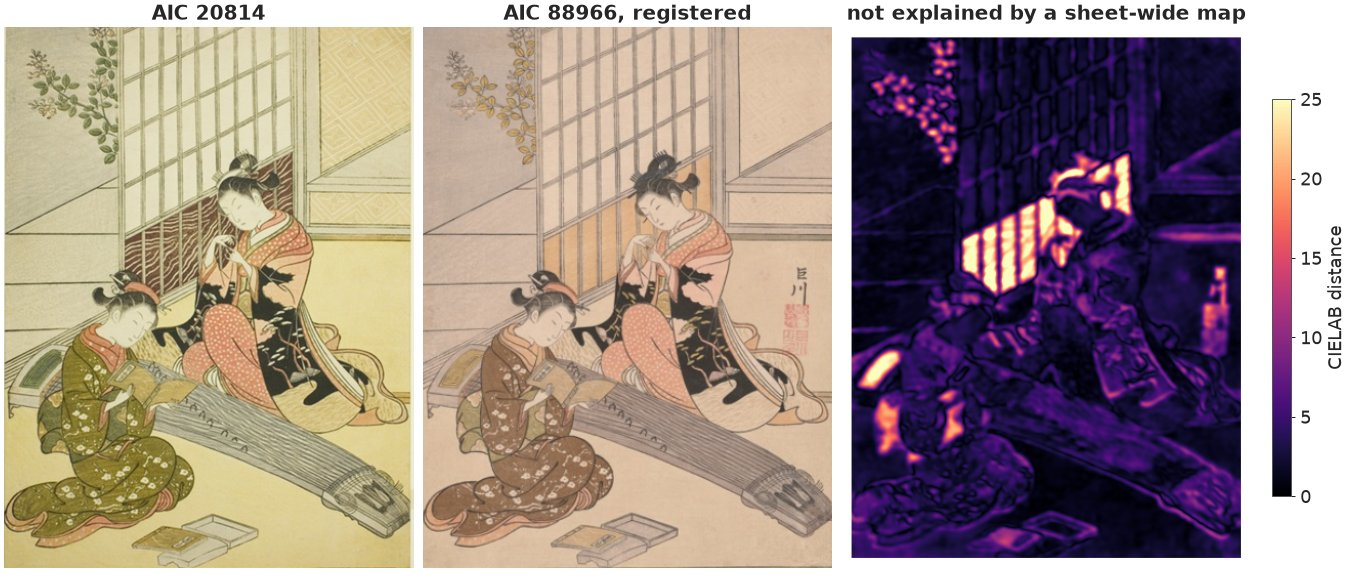

In [19]:
A = ndimage.gaussian_filter(LAB0, (2, 2, 0))[inside]
B = ndimage.gaussian_filter(LAB1, (2, 2, 0))[inside]
X = np.c_[A, np.ones(len(A))]
w = np.ones(len(A))
for _ in range(20):   # iteratively reweighted least squares with Huber weights
    M_aff = np.linalg.lstsq(X * w[:, None], B * w[:, None], rcond=None)[0]
    r = np.linalg.norm(B - X @ M_aff, axis=1)
    w = np.minimum(1, 3 / np.maximum(r, 1e-9))
resid = np.full(inside.shape, np.nan)
resid[inside] = r
print(f"after the sheet-wide colour map: median residual {np.median(r):.1f}, 95th percentile {np.quantile(r, 0.95):.1f} CIELAB units")

fig, axs = plt.subplots(1, 3, figsize=(15, 6.5))
axs[0].imshow(imgs[0])
axs[0].set_title(f"{IMP[0]}")
axs[1].imshow(np.clip(img1_on_0, 0, 1))
axs[1].set_title(f"{IMP[1]}, registered")
h = axs[2].imshow(resid, cmap="magma", vmin=0, vmax=25)
axs[2].set_title("not explained by a sheet-wide map")
plt.colorbar(h, ax=axs[2], shrink=0.7, label="CIELAB distance")
for ax in axs:
    ax.axis("off")
show_jpeg(fig)

Three places stand out. The **artist's seal** at right, present only in the second impression: a
positive control, the method finds a real difference. The **window lattice**, dark red-brown in
one and orange in the other: too different to be fading of the same ink (one is darker *and* redder),
most likely a different colour choice. And the **leaves** at top left: green in the first, yellow in
the second. That is exactly what a green made of dayflower blue and a yellow does as the blue goes.
The rest of the sheet, robes and floor included, changed together, in the way paper and photography
change a whole sheet.

### Calibrating the photographs against things that do not fade

A museum photograph is not a spectrophotometer. The two photographs render the same paper
differently (the second is about 8 units redder in $a^*$ everywhere). To compare them, each image
needs its own calibration, and that needs reference areas whose true colour is shared: the **bare
paper** (the white panes of the paper window, *shoji*) and **sumi**, the carbon-black ink of the
outlines and hair, which is chemically inert and does not fade. The leaves are measured *relative to
these anchors inside the same photograph*.

              AIC 20814            AIC 88966           
                      L    a     b         L    a     b
leaves             59.3 -7.0  23.6      63.8  5.0  20.6
paper (shoji)      88.8 -3.2  16.1      82.2  5.3  14.5
sumi, solid        24.5 -2.0   9.6      28.2  2.4   5.8
sumi, grey         58.7 -3.3  17.0      58.5  5.8   9.7
pixels per region: {'leaves': 2539, 'paper (shoji)': 3901, 'sumi, solid': 4419, 'sumi, grey': 2972}


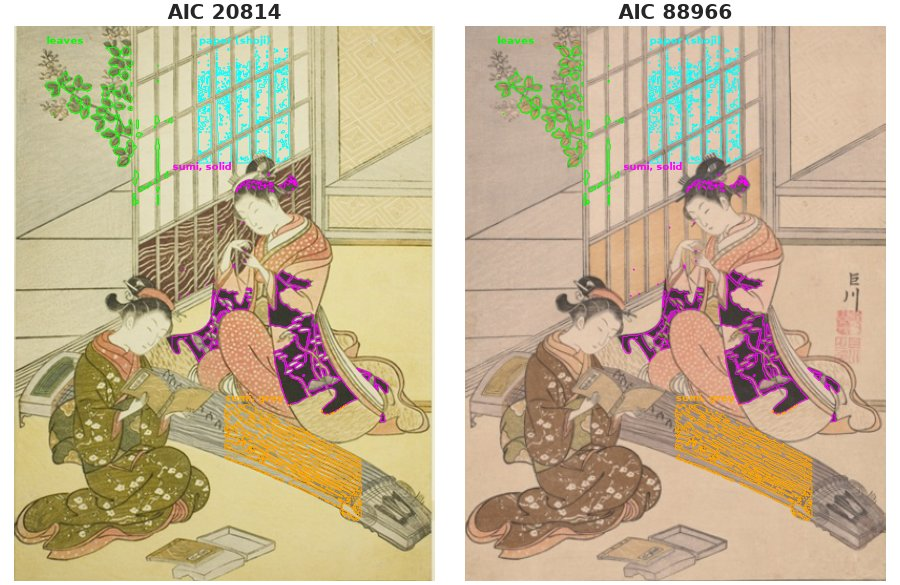

In [20]:
def box(y0, y1, x0, x1, cond):
    m = np.zeros(LAB0.shape[:2], bool)
    m[y0:y1, x0:x1] = True
    return m & cond & inside


lattice_panes = box(20, 130, 175, 265, np.ones(LAB0.shape[:2], bool))
REGIONS = {
    "leaves": box(20, 170, 20, 150, (LAB0[..., 1] < -5) & (LAB0[..., 0] < 82)),
    "paper (shoji)": box(20, 130, 175, 265, LAB0[..., 0] > np.quantile(LAB0[lattice_panes][:, 0], 0.6)),
    "sumi, solid": box(140, 420, 150, 360, LAB0[..., 0] < 30),
    "sumi, grey": box(360, 470, 200, 330, (LAB0[..., 0] > 45) & (LAB0[..., 0] < 65)
                      & (np.abs(LAB0[..., 1]) < 6) & (LAB0[..., 2] < 22)),
}
Y_reg = np.stack([[LAB0[m].mean(0), LAB1[m].mean(0)] for m in REGIONS.values()], 1)   # impression x region x Lab
print(pd.DataFrame({(imp, c): Y_reg[i, :, j] for i, imp in enumerate(IMP) for j, c in enumerate("Lab")},
                   index=list(REGIONS)).round(1))
print("pixels per region:", {k: int(m.sum()) for k, m in REGIONS.items()})

fig, axs = plt.subplots(1, 2, figsize=(10, 6.5))
for ax, img in zip(axs, [imgs[0], img1_on_0]):
    ax.imshow(np.clip(img, 0, 1))
    for (name, m), color in zip(REGIONS.items(), ["lime", "cyan", "magenta", "orange"]):
        ax.contour(m, levels=[0.5], colors=color, linewidths=0.8)
        ys, xs = np.nonzero(m)
        ax.text(xs.min(), ys.min() - 4, name, color=color, fontsize=8, fontweight="bold")
    ax.axis("off")
axs[0].set_title(IMP[0])
axs[1].set_title(IMP[1])
show_jpeg(fig)

### The two-impression model

For each impression $i$ and each region the model predicts a spectrum, renders it to CIELAB and
passes it through that photograph's calibration:

* **paper**: the measured paper spectrum plus a yellowing term $\gamma_i\,e^{-(\lambda-380)/60}$;
* **sumi**: paper plus a flat (grey) absorber, one amount for solid and one for grey areas, shared
  by both impressions (same blocks, inert carbon);
* **leaves**: paper plus a yellow and a blue colourant, $a_y\,\text{dye}_y(D_i) + a_b\,\text{dye}_b(D_i)$,
  where $\text{dye}(D)$ is the faded K/S of Part B at dose $D_i$. The amounts are **shared** by the
  two impressions (same blocks, same printing); the doses differ;
* **photograph**: $L \to s_L L + o_L$, $(a, b) \to s_C (a, b) + (o_a, o_b)$. The first photograph is
  assumed close to right (tight priors), the second gets loose ones;
* a common Gaussian error $\sigma$ in CIELAB units.

**Which colourants?** Harunobu's greens could be dayflower or indigo with turmeric, yellowwood or
orpiment. That is a discrete choice, a **recipe**, with six options. PyMC cannot sample a discrete
variable with NUTS, so it is **summed out**: each recipe has its own amounts, the likelihood is
$\log \sum_r \tfrac16\, p(\text{data} \mid r, \ldots)$, and the posterior probability of each recipe
is recovered afterwards from the per-recipe likelihoods.

**Doses** are in *xenon-equivalent* Mlxh, with a wide prior: median 1, 95% below about 20.

**Fading parameters** come from Part B, but not by refitting them here: the prints should not be
allowed to pull the laboratory rates around to explain a photograph (they would, freely, since a
photograph is a far weaker measurement). Instead each colourant's posterior (log rate, log shape, log
product amount, log product scale) is summarised by a multivariate normal and used as the prior.
This one-way flow of information is called **cut** inference. Rates are in xenon units, so the doses
are too.

In [21]:
YELLOWS, BLUES = ["turmeric", "yellowwood", "orpiment"], ["dayflower", "indigo"]
LEAF_COLS = YELLOWS + BLUES
RECIPES = [(y, b) for y in YELLOWS for b in BLUES]
x0 = spec[(spec.instrument == "XT") & (spec.dose_Mlxh == 0)].pivot(index="colourant", columns="wavelength", values="reflectance")
Kp0 = ks(x0.loc["paper"].to_numpy())
EPS = {c: ks(x0.loc[c].to_numpy()) - Kp0 for c in SINGLE}
YELLOW_SHAPE = np.exp(-(WL - 380) / 60)


def fade_params(idata, cols):
    """Stack (log k, log beta, log rho, log ell) draws per colourant: col x draw x 4 (xenon products:
    rates are in xenon units, and historical light was daylight)."""
    p = az.extract(idata)
    return np.stack([np.stack([p["logk"].sel(col=c).values, p["logbeta"].sel(col=c).values,
                               np.log(p["rho"].sel(inst="XT", col=c).values),
                               np.log(p["ell"].sel(inst="XT", col=c).values)], -1)
                     for c in cols])


par = fade_params(idata_fade, LEAF_COLS)
fp_mu = par.mean(1)
fp_chol = np.stack([np.linalg.cholesky(np.cov(p.T) + 1e-6 * np.eye(4)) for p in par])

coords = {"imp": IMP, "recipe": [f"{y} + {b}" for y, b in RECIPES], "leaf_col": LEAF_COLS,
          "fpar": ["logk", "logbeta", "logrho", "logell"], "part": ["yellow", "blue"]}
with pm.Model(coords=coords) as m_print:
    z = pm.Normal("z_fade", 0, 1, dims=("leaf_col", "fpar"))
    th = pm.Deterministic("fade_par", fp_mu + pt.einsum("cij,cj->ci", fp_chol, z), dims=("leaf_col", "fpar"))
    k, beta, rho, ell = (pt.exp(th[:, j]) for j in range(4))
    dose = pm.LogNormal("dose", 0, 1.5, dims="imp")
    q = pt.exp(-((k[None, :] * dose[:, None] + 1e-12) ** beta[None, :]))               # imp x colourant
    prod = pt.exp(-(WL[None, :] - 380) / ell[:, None])                                 # colourant x wl
    eps = np.stack([EPS[c] for c in LEAF_COLS])
    dye = q[..., None] * eps[None] + (rho[None, :] * (1 - q))[..., None] * prod[None]  # imp x colourant x wl
    gamma = pm.HalfNormal("paper_yellowing", 0.1, dims="imp")
    K_paper = Kp0[None] + gamma[:, None] * YELLOW_SHAPE[None]
    sumi = pm.LogNormal("sumi", np.log([3.0, 0.3]), 1.0, shape=2)
    amount = pm.LogNormal("amount", 0, 0.7, dims=("recipe", "part"))
    L_s = pm.Normal("L_scale", 1, np.array([0.03, 0.1]), dims="imp")
    L_o = pm.Normal("L_offset", 0, np.array([2.0, 8.0]), dims="imp")
    C_s = pm.LogNormal("chroma_scale", 0, np.array([0.05, 0.3]), dims="imp")
    a_o = pm.Normal("a_offset", 0, np.array([2.0, 8.0]), dims="imp")
    b_o = pm.Normal("b_offset", 0, np.array([2.0, 8.0]), dims="imp")
    sigma = pm.HalfNormal("sigma", 3.0)

    def photo(lab, i):
        return pt.stack([L_s[i] * lab[..., 0] + L_o[i], C_s[i] * lab[..., 1] + a_o[i],
                         C_s[i] * lab[..., 2] + b_o[i]], -1)

    anchors = 0
    for i in range(2):
        K_anchor = pt.stack([K_paper[i], K_paper[i] + sumi[0], K_paper[i] + sumi[1]])
        anchors += pm.logp(pm.Normal.dist(photo(lab_pt(km_reflectance(K_anchor)), i), sigma), Y_reg[i, 1:]).sum()
    per_recipe = []
    for r, (yc, bc) in enumerate(RECIPES):
        yi, bi = LEAF_COLS.index(yc), LEAF_COLS.index(bc)
        ll = 0
        for i in range(2):
            K = K_paper[i] + amount[r, 0] * dye[i, yi] + amount[r, 1] * dye[i, bi]
            ll += pm.logp(pm.Normal.dist(photo(lab_pt(km_reflectance(K)), i), sigma), Y_reg[i, 0]).sum()
        per_recipe.append(ll)
    per_recipe = pm.Deterministic("recipe_loglik", pt.stack(per_recipe), dims="recipe")
    pm.Potential("likelihood", anchors + pt.logsumexp(per_recipe) - np.log(len(RECIPES)))

    t0 = time.time()
    idata_print = pm.sample(random_seed=RANDOM_SEED, progressbar=False, target_accept=0.9)
print(f"sampled in {time.time() - t0:.0f} s; divergences: {int(idata_print.sample_stats['diverging'].sum())}")
print(az.summary(idata_print, var_names=["dose", "paper_yellowing", "sumi", "L_scale", "chroma_scale",
                                         "a_offset", "b_offset", "sigma"], round_to=2)
      [["mean", "sd", "eti89_lb", "eti89_ub", "ess_bulk", "r_hat"]])

sampled in 11 s; divergences: 2
                            mean    sd  eti89_lb  eti89_ub  ess_bulk  r_hat
dose[AIC 20814]             0.76  0.99      0.06      2.44   5416.16    1.0
dose[AIC 88966]             2.97  5.48      0.15      8.27   3592.31    1.0
paper_yellowing[AIC 20814]  0.08  0.06      0.01      0.19   3020.16    1.0
paper_yellowing[AIC 88966]  0.08  0.06      0.01      0.19   3203.15    1.0
sumi[0]                     8.47  2.31      5.39     12.37   2247.23    1.0
sumi[1]                     0.72  0.19      0.44      1.03   3165.40    1.0
L_scale[AIC 20814]          1.00  0.02      0.96      1.03   5560.62    1.0
L_scale[AIC 88966]          0.95  0.06      0.85      1.05   1483.08    1.0
chroma_scale[AIC 20814]     1.00  0.05      0.92      1.08   7556.12    1.0
chroma_scale[AIC 88966]     0.79  0.16      0.56      1.07   3378.43    1.0
a_offset[AIC 20814]        -1.54  1.40     -3.72      0.67   7450.42    1.0
a_offset[AIC 88966]         4.78  1.89      1.77      7.

In [22]:
ll_r = idata_print.posterior["recipe_loglik"].values.reshape(-1, len(RECIPES))
w_r = np.exp(ll_r - ll_r.max(1, keepdims=True))
w_r /= w_r.sum(1, keepdims=True)
recipe_prob = pd.Series(w_r.mean(0), index=coords["recipe"])
print("posterior probability of each recipe for the green of the leaves:")
print(recipe_prob.sort_values(ascending=False).round(3))
dose_draws = idata_print.posterior["dose"].values.reshape(-1, 2)
print("\nxenon-equivalent dose (Mlxh), 5% / 50% / 95%:")
print(pd.DataFrame(np.quantile(dose_draws, [0.05, 0.5, 0.95], 0).T, index=IMP, columns=["5%", "50%", "95%"]).round(2))
print(f"P(the second impression has seen more light) = {(dose_draws[:, 1] > dose_draws[:, 0]).mean():.2f}")

posterior probability of each recipe for the green of the leaves:
yellowwood + dayflower    0.464
turmeric + dayflower      0.304
orpiment + dayflower      0.218
orpiment + indigo         0.007
yellowwood + indigo       0.005
turmeric + indigo         0.002
dtype: float64

xenon-equivalent dose (Mlxh), 5% / 50% / 95%:
             5%   50%   95%
AIC 20814  0.06  0.45  2.53
AIC 88966  0.14  1.75  8.72
P(the second impression has seen more light) = 0.79


The blue of the leaves is almost certainly **dayflower**, not indigo: indigo is so light-fast that
no plausible dose turns the first impression's green into the second's yellow. That is also what
the history of the period says (dayflower was the common blue of the 1760s prints), but the model got
there from colour alone. **Which yellow** it cannot say: turmeric, yellowwood and orpiment all
explain the data, because once the blue is accounted for, the yellow part hardly changes between
the two impressions.

The **doses** are uncertain in absolute terms (90% intervals span one to two orders of magnitude)
but the second impression has probably seen more light. Why so vague? A photograph measures the
colour *today*, which fixes roughly the product "amount of blue x fraction of it left". It does not
say how strong the print was to begin with: a strong print that lost much or a weak print that lost
little look alike, so the prior on the amounts does much of the work. What the two impressions add
is a comparison (same amounts, different doses), and that is better determined: the fraction of
the blue that is left in each impression, and the ratio of their doses.

fraction of dayflower left, median (90%): {'AIC 20814': '0.82 (0.47-0.96)', 'AIC 88966': '0.57 (0.13-0.93)'}
dose ratio, median 3.5; P(ratio > 2) = 0.65


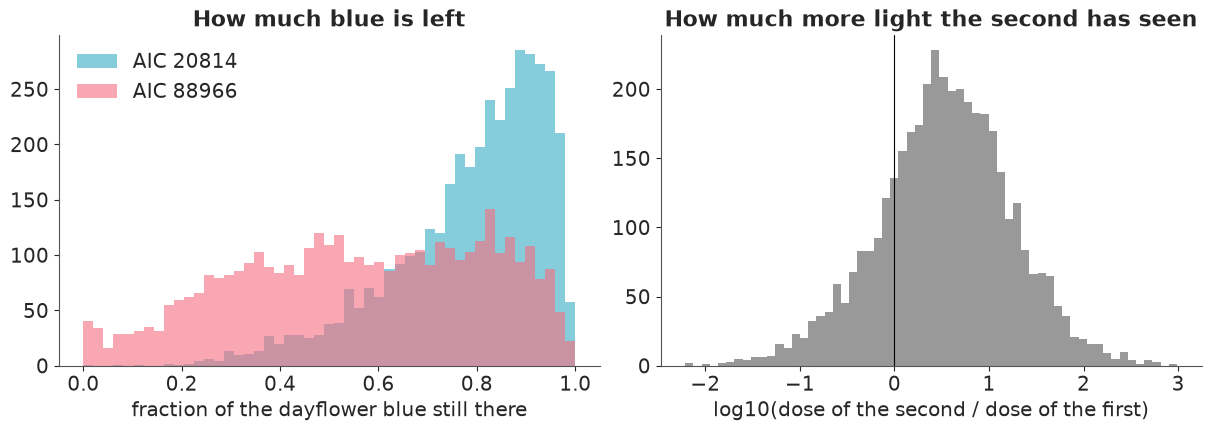

In [23]:
post_p = idata_print.posterior
best = int(recipe_prob.values.argmax())
th_d = post_p["fade_par"].sel(leaf_col="dayflower")
k_d, b_d = np.exp(th_d.sel(fpar="logk")), np.exp(th_d.sel(fpar="logbeta"))
q_blue = np.exp(-((k_d * post_p["dose"]) ** b_d)).values.reshape(-1, 2)
fig, axs = plt.subplots(1, 2, figsize=(12, 4.2))
bins = np.linspace(0, 1, 50)
for i, c in enumerate(["C0", "C1"]):
    axs[0].hist(q_blue[:, i], bins=bins, color=c, alpha=0.6, label=IMP[i])
axs[0].set_xlabel("fraction of the dayflower blue still there")
axs[0].legend()
axs[0].set_title("How much blue is left")
ratio = dose_draws[:, 1] / dose_draws[:, 0]
axs[1].hist(np.log10(ratio), bins=60, color="0.6")
axs[1].axvline(0, color="k", lw=0.8)
axs[1].set_xlabel("log10(dose of the second / dose of the first)")
axs[1].set_title("How much more light the second has seen");
print("fraction of dayflower left, median (90%):",
      {IMP[i]: f"{np.median(q_blue[:, i]):.2f} ({np.quantile(q_blue[:, i], 0.05):.2f}-{np.quantile(q_blue[:, i], 0.95):.2f})" for i in range(2)})
print(f"dose ratio, median {np.median(ratio):.1f}; P(ratio > 2) = {(ratio > 2).mean():.2f}")

The first impression keeps most of its blue (about four-fifths of the dayflower is left), the
second a bit over half, both with wide intervals; the second has seen about 3.5 times the light (median),
though the probability that it is more than twice is only about two in three.

### From the leaves to the whole print: a grid posterior per colour area

To restore the whole print, divide it into colour areas (k-means on the first impression's CIELAB,
10 clusters; the registered second impression has the same geometry, so the same areas apply to it)
and ask of each area what the leaves model asked: which colourant(s), how much, given the doses.
Both impressions are used, with the same recipe and amounts in both (same blocks, same printing).
For the doses, the photographs' calibrations and the paper, take draws from the two-impression
posterior; for the fading parameters, draws from Part B.

Each area has a **discrete recipe** (bare paper, sumi, any of the 13 colourants alone, the six
greens, safflower over dayflower for purple) and one or two **amounts**. That space is tiny but
badly multimodal (a pink could be a little safflower or much faded cochineal), which is exactly
where NUTS struggles and a **grid** is exact: for every posterior draw of the shared quantities,
evaluate the likelihood on a grid of amounts for every recipe, normalise, and sample a recipe and an
amount from it. The result is a posterior draw of every area's *original* colour: the colour the
recipe renders to with no fading, on unyellowed paper, seen by the standard observer in daylight.

In [24]:
lab0_s = ndimage.gaussian_filter(LAB0, (1.5, 1.5, 0))
flat = lab0_s[inside]
centres, _ = kmeans2(flat[rng.choice(len(flat), 20000, replace=False)], 10, seed=RANDOM_SEED, minit="++")
labels = np.argmin(((lab0_s.reshape(-1, 3)[:, None, :] - centres[None]) ** 2).sum(-1), 1).reshape(LAB0.shape[:2])
cluster_lab = np.stack([[L[(labels == j) & inside].mean(0) for j in range(10)] for L in (LAB0, LAB1)])  # imp x area x Lab
cluster_share = np.array([((labels == j) & inside).mean() for j in range(10)])
order_c = np.argsort(-cluster_lab[0, :, 0])            # light to dark
print(pd.DataFrame(np.c_[cluster_lab[0], cluster_lab[1], 100 * cluster_share],
                   columns=["L 1st", "a 1st", "b 1st", "L 2nd", "a 2nd", "b 2nd", "% of image"]).iloc[order_c].round(1))

   L 1st  a 1st  b 1st  L 2nd  a 2nd  b 2nd  % of image
0   84.1   -3.4   29.6   79.4    6.0   17.7        15.7
2   82.9   -3.2   18.4   76.7    5.3   13.2        24.0
4   78.8   -2.5   32.4   76.6    6.1   17.6         7.9
5   70.0   -3.5   19.9   64.5    5.3   11.5        16.4
7   66.8   14.5   29.7   69.2   15.4   21.8         4.2
3   64.9   -0.7   32.5   65.0    7.1   17.9         5.1
8   52.3    0.0   20.1   60.4    6.8   17.4         7.4
1   51.5   -3.8   39.5   51.1    9.5   19.6         5.0
6   45.3   -3.3   31.3   51.2    7.0   19.1         2.7
9   28.6   -1.6   10.3   31.7    2.8    6.6         2.9


In [25]:
GRID1 = np.exp(np.linspace(np.log(0.03), np.log(6), 40))            # one amount
G2 = np.exp(np.linspace(np.log(0.05), np.log(5), 16))
GRID2 = np.stack(np.meshgrid(G2, G2, indexing="ij"), -1).reshape(-1, 2)   # two amounts
SUMI_GRID = np.exp(np.linspace(np.log(0.01), np.log(30), 60))
CANDIDATES = ([("bare paper", ())] + [("sumi", ("sumi",))] + [(c, (c,)) for c in SINGLE]
              + [(f"{y} + {b}", (y, b)) for y, b in RECIPES] + [("safflower + dayflower", ("safflower", "dayflower"))])
rec_names = [n for n, _ in CANDIDATES]


def log_prior_amount(a, sd=0.7):
    return -0.5 * (np.log(a) / sd) ** 2      # log-normal(0, sd) on a log-spaced grid (the Jacobian cancels)


def render(K):
    return spectra_to_lab(km_reflectance(np.maximum(K, 1e-6)))


def grid_posterior(n_draws=200, seed=3):
    """Per shared posterior draw, sample (recipe, amounts) for every area from its exact grid posterior
    given both impressions. Returns the original colour (true CIELAB), today's modelled colour in each
    photograph, the original seen through each photograph, and the recipe index."""
    g = np.random.default_rng(seed)
    pp = az.extract(idata_print, num_samples=n_draws, random_seed=seed)
    pf = az.extract(idata_fade, num_samples=n_draws, random_seed=seed + 1)
    out = {"orig": np.zeros((n_draws, 10, 3)), "now_photo": np.zeros((n_draws, 2, 10, 3)),
           "orig_photo": np.zeros((n_draws, 2, 10, 3)), "recipe": np.zeros((n_draws, 10), int)}
    for d in range(n_draws):
        def photo(lab, i):
            return np.stack([pp["L_scale"].values[i, d] * lab[..., 0] + pp["L_offset"].values[i, d],
                             pp["chroma_scale"].values[i, d] * lab[..., 1] + pp["a_offset"].values[i, d],
                             pp["chroma_scale"].values[i, d] * lab[..., 2] + pp["b_offset"].values[i, d]], -1)

        faded = []                                   # per impression: colourant -> faded K/S
        for i in range(2):
            D = pp["dose"].values[i, d]
            f_i = {}
            for j, c in enumerate(SINGLE):
                k, b = np.exp(pf["logk"].values[j, d]), np.exp(pf["logbeta"].values[j, d])
                qq = np.exp(-((k * D) ** b))
                prod = np.exp(-(WL - 380) / pf["ell"].sel(inst="XT").values[j, d])
                f_i[c] = qq * EPS[c] + pf["rho"].sel(inst="XT").values[j, d] * (1 - qq) * prod
            faded.append(f_i)
        paper_now = [Kp0 + pp["paper_yellowing"].values[i, d] * YELLOW_SHAPE for i in range(2)]
        now, orig, lp, rid = [[], []], [], [], []
        for r, (name, parts) in enumerate(CANDIDATES):
            if not parts:
                A, prior_lp = np.zeros((1, 0)), np.zeros(1)
            elif parts == ("sumi",):
                A, prior_lp = SUMI_GRID[:, None], log_prior_amount(SUMI_GRID, 1.5)
            elif len(parts) == 1:
                A, prior_lp = GRID1[:, None], log_prior_amount(GRID1)
            else:
                A, prior_lp = GRID2, log_prior_amount(GRID2[:, 0]) + log_prior_amount(GRID2[:, 1])

            def mix(base, dyes):
                K = np.broadcast_to(base, (len(A), len(WL))).copy()
                for m, part in enumerate(parts):
                    K += A[:, m:m + 1] * (np.ones(len(WL)) if part == "sumi" else dyes[part])
                return K

            for i in range(2):
                now[i].append(photo(render(mix(paper_now[i], faded[i])), i))
            orig.append(render(mix(Kp0, EPS)))
            lp.append(prior_lp - np.log(len(prior_lp)) - np.log(len(CANDIDATES)))  # uniform over recipes
            rid.append(np.full(len(prior_lp), r))
        now = [np.concatenate(n) for n in now]
        orig, lp, rid = np.concatenate(orig), np.concatenate(lp), np.concatenate(rid)
        sig = pp["sigma"].values[d]
        logits = lp[None] + sum(-0.5 * (((cluster_lab[i][:, None, :] - now[i][None]) / sig) ** 2).sum(-1)
                                for i in range(2))                                  # area x grid
        p = np.exp(logits - logits.max(1, keepdims=True))
        p /= p.sum(1, keepdims=True)
        pick = np.array([g.choice(len(lp), p=p[j]) for j in range(10)])
        out["orig"][d], out["recipe"][d] = orig[pick], rid[pick]
        for i in range(2):
            out["now_photo"][d, i] = now[i][pick]
            out["orig_photo"][d, i] = photo(orig[pick], i)
    return out


t0 = time.time()
gp = grid_posterior()
print(f"grid posterior: {time.time() - t0:.0f} s")
shift = gp["orig_photo"] - gp["now_photo"]                    # draw x impression x area x Lab
summary_rows = []
for j in order_c:
    counts = pd.Series(gp["recipe"][:, j]).value_counts(normalize=True)
    top = ", ".join(f"{rec_names[i]} {v:.2f}" for i, v in counts.head(3).items())
    fit = [de2000(np.median(gp["now_photo"][:, i, j], 0), cluster_lab[i, j]) for i in range(2)]
    rest = [np.median(de2000(gp["now_photo"][:, i, j], gp["orig_photo"][:, i, j])) for i in range(2)]
    summary_rows.append((j, f"{100 * cluster_share[j]:.0f}%", f"{fit[0]:.1f} / {fit[1]:.1f}",
                         f"{rest[0]:.1f} / {rest[1]:.1f}", top))
print(pd.DataFrame(summary_rows, columns=["area", "share", "fit ΔE00 (1st / 2nd)",
                                          "restoration ΔE00 (1st / 2nd)", "most probable recipes"]).to_string(index=False))

grid posterior: 2 s
 area share fit ΔE00 (1st / 2nd) restoration ΔE00 (1st / 2nd)                                                             most probable recipes
    0   16%            3.2 / 1.7                    0.9 / 1.0                                        turmeric 0.31, bare paper 0.28, ochre 0.20
    2   24%            1.3 / 3.5                    0.7 / 0.6                                        bare paper 0.67, sumi 0.15, dayflower 0.14
    4    8%            3.0 / 2.8                    1.5 / 2.4                                        turmeric 0.54, yellowwood 0.15, ochre 0.10
    5   16%            2.4 / 4.5                    1.3 / 1.8                 turmeric + dayflower 0.46, sumi 0.32, yellowwood + dayflower 0.09
    7    4%            5.8 / 3.7                    0.4 / 0.3                                      red lead 0.67, vermilion 0.18, turmeric 0.07
    3    5%            1.5 / 3.5                    2.1 / 3.6 turmeric + dayflower 0.53, yellowwood + dayflower 0.37

Reading the table (areas from light to dark):

* The **paper-coloured areas** (0, 2) are most probably bare paper, but not certainly: the cream of
  area 0 could also be a faint yellow. The **yellow floor** (area 4) is most probably turmeric.
* The **olive, khaki and brown areas** (5, 3, 8, 1, 6: robes, window frames, the lattice, leaves)
  are dayflower greens, with turmeric or yellowwood as the yellow; which yellow stays open.
* The **pink** (area 7) comes out as red lead or vermilion, stable minerals, so it barely changes.
  Safflower was a candidate, but its pink is bluer than this orange-pink today.
* The **black** (area 9) is sumi.

The "fit" column is a warning light. Several areas are off by 4-7 ΔE00 in one impression or the
other: k-means areas mix pixels of different inks (the lattice and the robe patterns share an area),
and the lattice was not printed the same way in both impressions. The restorations are largest for
the dayflower greens of the second impression (3-4 ΔE00) and about half that in the first, which
kept more of its blue.

In [26]:
def restored(d, i):
    img_lab = LAB0 if i == 0 else LAB1
    return lab_to_srgb(img_lab + shift[d, i][labels])

## F. Showing uncertainty when the estimate is a colour

The obvious uncertainty displays all use colour to encode uncertainty, and colour is taken. Five
displays that work anyway, then the dose itself:

### 1. Split swatches

One swatch per area, cut into three: the least, the median and the most restored of the posterior
draws of its *original* colour (ordered by how far each is from today's), between the area's colour
today in each impression (calibrated to true colour, so the three are comparable). The fan of colours
inside each swatch is the uncertainty, shown *as colour*, which is what a viewer needs to judge.

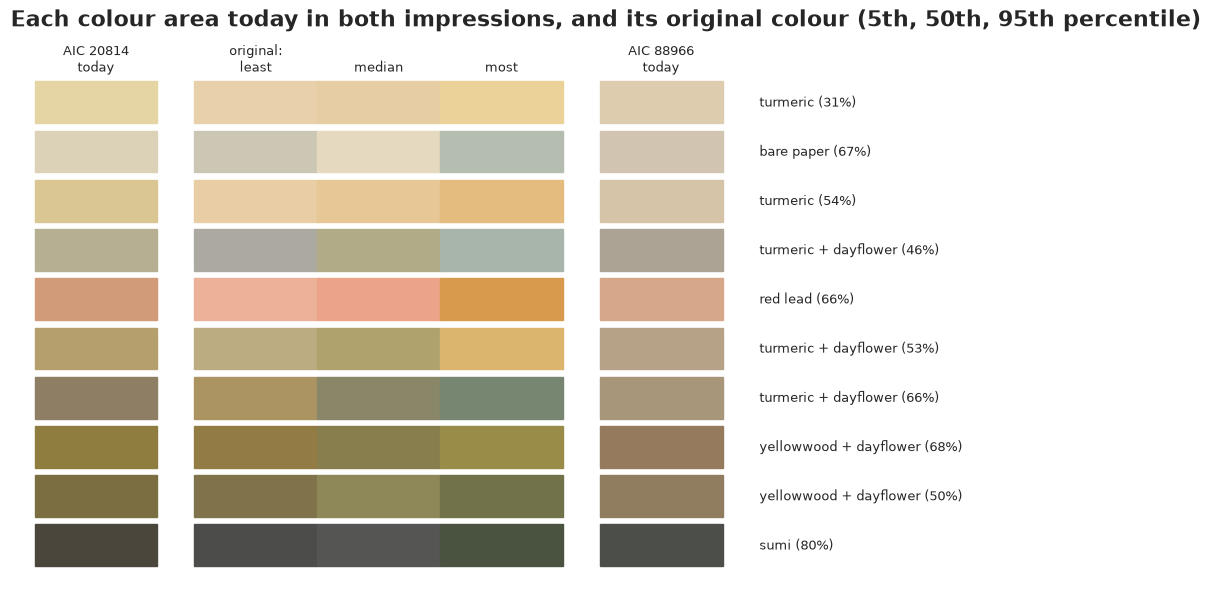

In [27]:
def calibrated(lab, i, pp=idata_print.posterior):
    Ls, Lo = float(pp["L_scale"].isel(imp=i).mean()), float(pp["L_offset"].isel(imp=i).mean())
    Cs = float(pp["chroma_scale"].isel(imp=i).mean())
    ao, bo = float(pp["a_offset"].isel(imp=i).mean()), float(pp["b_offset"].isel(imp=i).mean())
    return np.stack([(lab[..., 0] - Lo) / Ls, (lab[..., 1] - ao) / Cs, (lab[..., 2] - bo) / Cs], -1)


fig, ax = plt.subplots(figsize=(12, 5.8))
for row, j in enumerate(order_c):
    today = [calibrated(cluster_lab[i, j], i) for i in range(2)]
    de_now = de2000(today[1], gp["orig"][:, j])
    idx = np.argsort(de_now)
    picks = [idx[int(0.05 * len(idx))], idx[len(idx) // 2], idx[int(0.95 * len(idx))]]
    y = -row
    ax.add_patch(plt.Rectangle((0, y), 1, 0.85, color=lab_to_srgb(today[0])))
    for s_, pk in enumerate(picks):
        ax.add_patch(plt.Rectangle((1.3 + s_, y), 1, 0.85, color=lab_to_srgb(gp["orig"][pk, j])))
    ax.add_patch(plt.Rectangle((4.6, y), 1, 0.85, color=lab_to_srgb(today[1])))
    counts = pd.Series(gp["recipe"][:, j]).value_counts(normalize=True)
    ax.text(5.9, y + 0.42, f"{rec_names[counts.index[0]]} ({counts.iloc[0]:.0%})", va="center", fontsize=9)
for x, t in zip([0.5, 1.8, 2.8, 3.8, 5.1], [f"{IMP[0]}\ntoday", "original:\nleast", "\nmedian", "\nmost",
                                             f"{IMP[1]}\ntoday"]):
    ax.text(x, 1.05, t, ha="center", fontsize=9)
ax.set_xlim(-0.2, 9.5)
ax.set_ylim(-len(order_c) + 0.7, 1.8)
ax.axis("off")
ax.set_title("Each colour area today in both impressions, and its original colour (5th, 50th, 95th percentile)");

### 2. Restorations as hypothetical outcomes

"The print as it might have looked", several times over, each a posterior draw applied to each
impression's photograph. Viewers judge the range of plausible originals directly, without having to
read an interval: what is the same in every panel is certain, the rest is not. Each draw restores
*both* impressions, which should then look alike where they were printed alike. The animated version
cycles through forty draws of the more faded impression; stable areas stand still and uncertain ones
flicker.

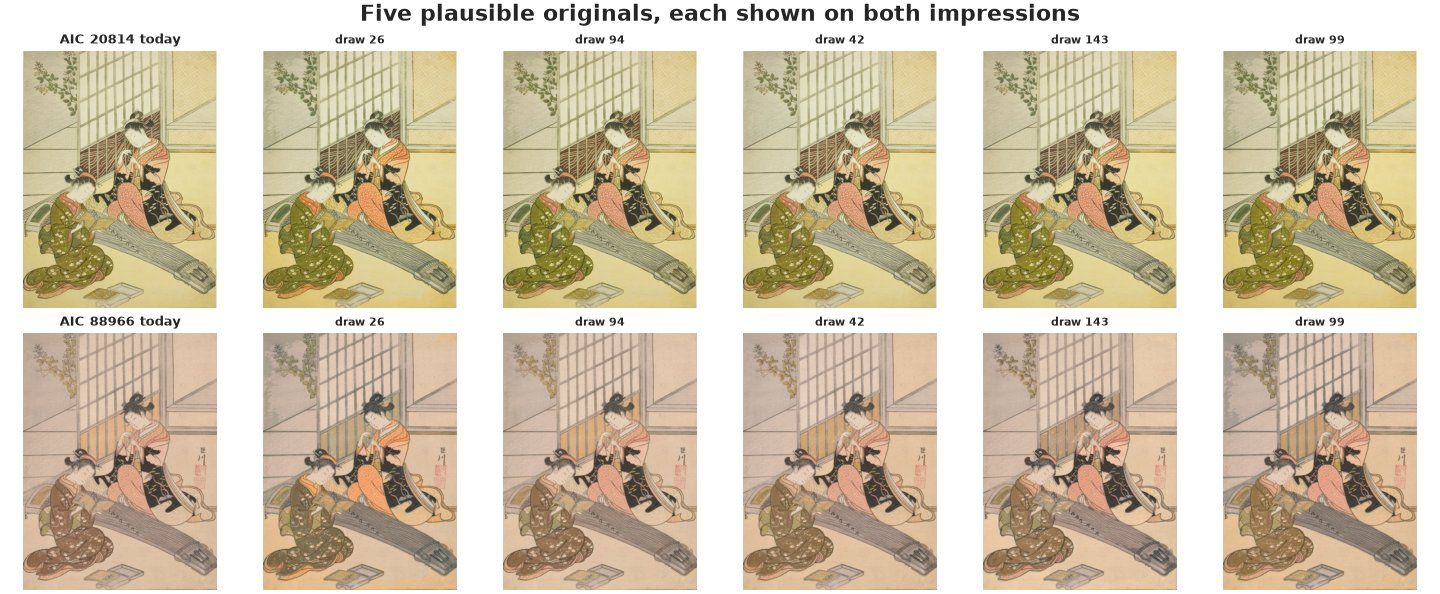

In [28]:
picks = rng.choice(len(shift), 5, replace=False)
fig, axs = plt.subplots(2, 6, figsize=(16, 6.6))
for i in range(2):
    axs[i, 0].imshow(imgs[0] if i == 0 else np.clip(img1_on_0, 0, 1))
    axs[i, 0].set_title(f"{IMP[i]} today", fontsize=10)
    for ax, d in zip(axs[i, 1:], picks):
        ax.imshow(restored(d, i))
        ax.set_title(f"draw {d}", fontsize=9)
for ax in axs.ravel():
    ax.axis("off")
fig.suptitle("Five plausible originals, each shown on both impressions")
show_jpeg(fig)

In [29]:
small = ndimage.zoom(LAB1, (0.5, 0.5, 1), order=1)
labels_small = labels[::2, ::2][: small.shape[0], : small.shape[1]]
fig, axs = plt.subplots(1, 2, figsize=(5.6, 3.9), dpi=72)
axs[0].imshow(lab_to_srgb(small))
axs[0].set_title("today", fontsize=8)
frame = axs[1].imshow(lab_to_srgb(small))
for ax in axs:
    ax.axis("off")


def update(k):
    frame.set_data(lab_to_srgb(small + shift[k, 1][labels_small]))
    axs[1].set_title(f"restored, posterior draw {k}", fontsize=8)
    return (frame,)


anim = animation.FuncAnimation(fig, update, frames=range(40), interval=400)
plt.close(fig)
with plt.rc_context({"animation.frame_format": "jpeg"}):     # photographs: JPEG frames are far smaller
    display(HTML(anim.to_jshtml(default_mode="loop")))

### 3. Trajectory tubes

For the leaves, where the two-impression model is richest, show the whole path from the original
colour towards today's, one faint line per posterior draw, in the $a^*b^*$ plane (true colour). The
spread of the paths *is* the uncertainty; where they bundle, the model is sure. The large markers
are the two impressions' leaves today, with each photograph's calibration undone.

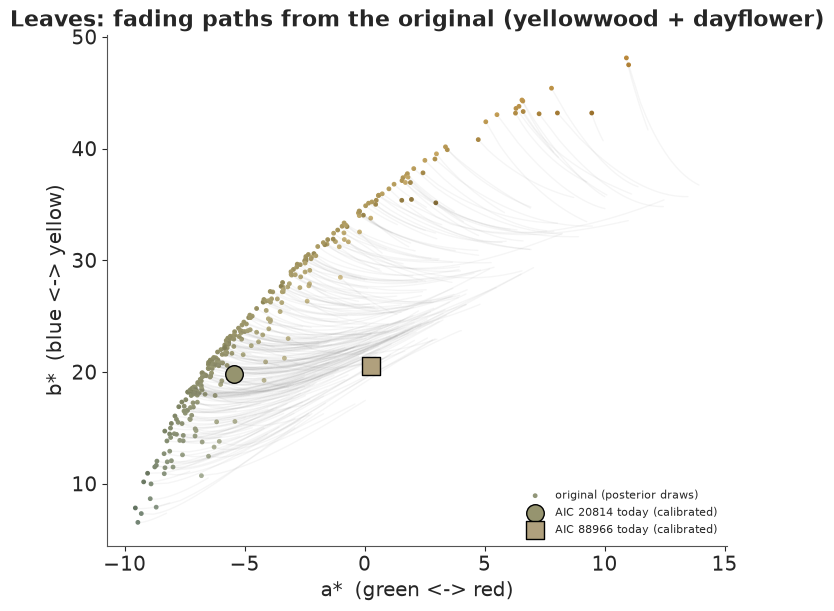

In [30]:
pp = az.extract(idata_print, num_samples=300, random_seed=5)
yi, bi = LEAF_COLS.index(RECIPES[best][0]), LEAF_COLS.index(RECIPES[best][1])
fig, ax = plt.subplots(figsize=(7, 6))
originals = []
for d in range(300):
    th = pp["fade_par"].values[..., d]
    Hs = np.linspace(0, pp["dose"].values[:, d].max(), 60)
    a_y, a_b = pp["amount"].values[best, :, d]
    Kpap = Kp0 + pp["paper_yellowing"].values[0, d] * YELLOW_SHAPE
    K = np.broadcast_to(Kpap, (len(Hs), len(WL))).copy()
    for c_i, a in [(yi, a_y), (bi, a_b)]:
        k, b, rho_, ell_ = np.exp(th[c_i])
        qq = np.exp(-((k * Hs) ** b))[:, None]
        K += a * (qq * EPS[LEAF_COLS[c_i]] + rho_ * (1 - qq) * np.exp(-(WL - 380) / ell_))
    path = render(K)
    ax.plot(path[:, 1], path[:, 2], color="0.3", alpha=0.05, lw=1)
    originals.append(path[0])
originals = np.array(originals)
ax.scatter(originals[:, 1], originals[:, 2], s=6, c=lab_to_srgb(originals), label="original (posterior draws)")
for i, mk in enumerate(["o", "s"]):
    cal = calibrated(Y_reg[i, 0], i)
    ax.scatter(cal[1], cal[2], marker=mk, s=160, color=lab_to_srgb(cal), edgecolor="k", zorder=4,
               label=f"{IMP[i]} today (calibrated)")
ax.set_xlabel("a*  (green <-> red)")
ax.set_ylabel("b*  (blue <-> yellow)")
ax.legend(fontsize=8, loc="lower right")
ax.set_title(f"Leaves: fading paths from the original ({RECIPES[best][0]} + {RECIPES[best][1]})");

The plausible originals (small dots, each in its own colour) lie along a curve from a blue-green
to an ochre: the photographs fix today's colour but not the balance of blue and yellow in the new
print, so the prior on the amounts keeps that range open. Every path moves the same way, to the
right (losing blue), and the first impression sits close to the originals while the second is far
along. **What is certain is the direction of change, not the starting shade.**

### 4. A visibility map

How different are the plausible originals *from each other*, area by area? Measure it in the unit
that matters: ΔE00 between pairs of posterior draws of the original colour. Where the typical
difference is below 1, no viewer could tell the draws apart, so the uncertainty is invisible and is
shown as flat grey. Above 1 a sequential scale shows how much the originals disagree. Because this
map shows a *difference*, not a colour, colour is free to encode it again.

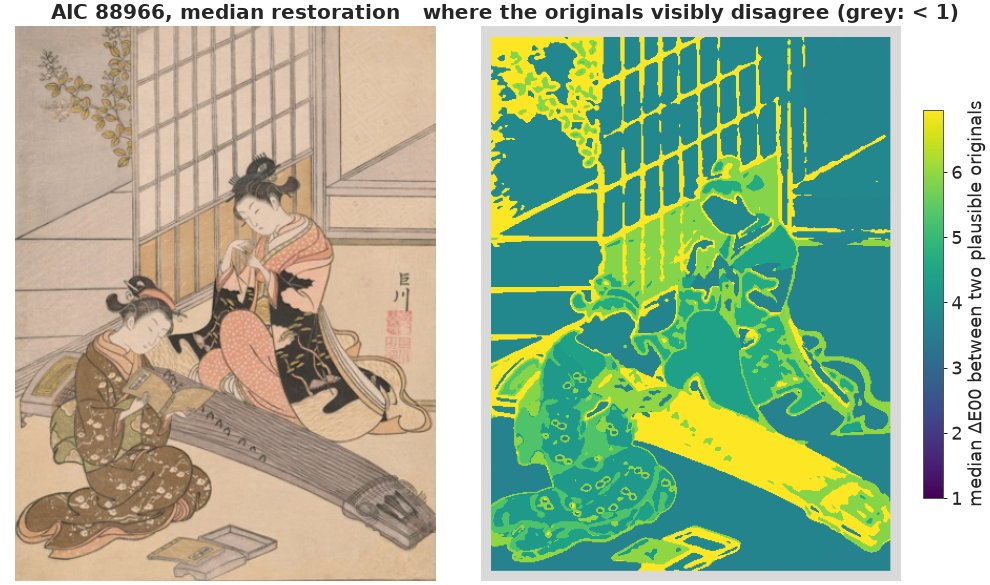

area 0    3.7
area 2    3.8
area 4    3.7
area 5    7.8
area 7    4.4
area 3    6.0
area 8    5.9
area 1    4.2
area 6    5.3
area 9    4.7


In [31]:
pairs = rng.choice(len(gp["orig"]), (150, 2))
de_pair = np.array([de2000(gp["orig"][i], gp["orig"][j]) for i, j in pairs])    # pair x area
spread = np.median(de_pair, 0)
vis = np.where(inside, spread[labels], np.nan)
fig, axs = plt.subplots(1, 2, figsize=(11, 6.5))
axs[0].imshow(lab_to_srgb(LAB1 + np.median(shift[:, 1], 0)[labels]))
axs[0].set_title(f"{IMP[1]}, median restoration")
masked = np.ma.masked_where(~(vis >= 1), vis)
axs[1].imshow(np.full(vis.shape, 0.85), cmap="gray", vmin=0, vmax=1)
h = axs[1].imshow(masked, cmap="viridis", vmin=1, vmax=max(2, float(np.quantile(spread, 0.95))))
plt.colorbar(h, ax=axs[1], shrink=0.7, label="median ΔE00 between two plausible originals")
axs[1].set_title("where the originals visibly disagree (grey: < 1)")
for ax in axs:
    ax.axis("off")
show_jpeg(fig)
print(pd.Series(spread[order_c], index=[f"area {j}" for j in order_c]).round(1).to_string())

No area is below 1: the plausible originals disagree visibly *everywhere*, by about 3.5 (paper, the
pink) to 8 (area 5) ΔE00. Two sources: which recipe (area 5 is a dayflower green in some draws and sumi grey in
others), and how much of it (the photographs cannot pin down the amounts). A map that is uniformly
"visibly uncertain" is still informative: the model says *what kind* of colour each area was, not
its exact shade, and a restorer should not paint one.

### 5. Recipe probabilities without colour

Which colourant is where is a categorical uncertainty. Drawn as colour it would clash with the
picture, so draw each area as a silhouette and give the recipe probabilities as bars: position and
length, not hue.

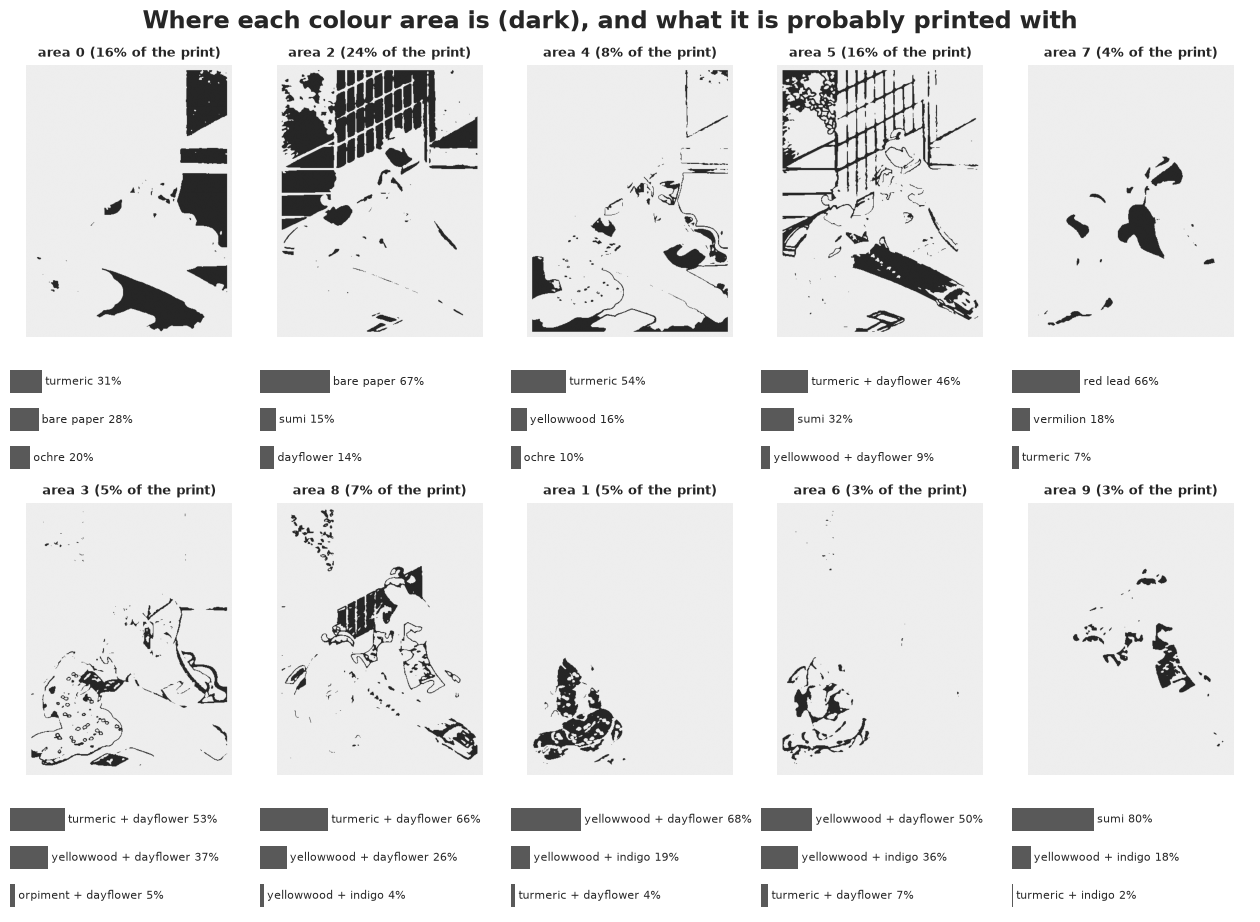

In [32]:
fig, axs = plt.subplots(4, 5, figsize=(16, 11), layout="none",
                        gridspec_kw={"height_ratios": [3, 1.2, 3, 1.2], "hspace": 0.15, "wspace": 0.05})
for n, j in enumerate(order_c):
    ax_img, ax_bar = axs[2 * (n // 5), n % 5], axs[2 * (n // 5) + 1, n % 5]
    ax_img.imshow(np.where((labels == j) & inside, 0.15, 0.93), cmap="gray", vmin=0, vmax=1)
    ax_img.set_title(f"area {j} ({100 * cluster_share[j]:.0f}% of the print)", fontsize=9)
    counts = pd.Series(gp["recipe"][:, j]).value_counts(normalize=True).head(3)[::-1]
    ax_bar.barh(range(len(counts)), counts.values, color="0.35", height=0.6)
    for r, (i, v) in enumerate(counts.items()):
        ax_bar.text(v + 0.03, r, f"{rec_names[i]} {v:.0%}", va="center", fontsize=8)
    ax_bar.set_xlim(0, 2.3)
    for ax in (ax_img, ax_bar):
        ax.axis("off")
fig.suptitle("Where each colour area is (dark), and what it is probably printed with", y=0.93);

### 6. How much light has the print seen?

The dose posterior is in xenon-equivalent Mlxh. Turned into *years on display at 50 lux, 8 hours a
day, 300 days a year* (0.12 Mlxh per year), it needs the transfer question of Part C: is a gallery
lux-hour as damaging as a xenon one (daylight through glass, with its UV), or as mild as a
microfading one (UV-free LED)? The two answers bracket the truth for modern, UV-filtered lighting.

           as daylight (median years)  as UV-free LED (median years)
AIC 20814                         4.0                          100.0
AIC 88966                        15.0                          377.0


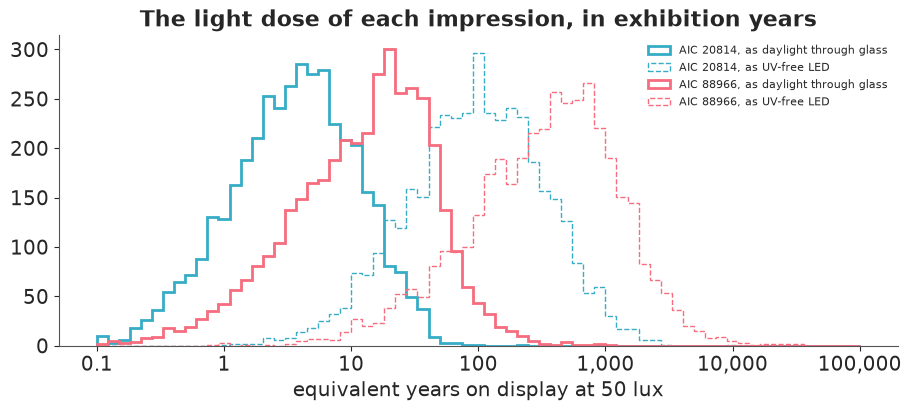

In [33]:
tau_day = np.exp(post_fade["logtau"].sel(col="dayflower").values.reshape(-1))
per_year = 50 * 8 * 300 / 1e6
years_xenon = dose_draws / per_year
years_led = dose_draws / (per_year * rng.choice(tau_day, len(dose_draws))[:, None])
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(-1, 5, 70)
for i, c in enumerate(["C0", "C1"]):
    ax.hist(np.log10(years_xenon[:, i]), bins=bins, histtype="step", color=c, lw=2, label=f"{IMP[i]}, as daylight through glass")
    ax.hist(np.log10(years_led[:, i]), bins=bins, histtype="step", color=c, lw=1, ls="--", label=f"{IMP[i]}, as UV-free LED")
ax.set_xticks(range(-1, 6))
ax.set_xticklabels(["0.1", "1", "10", "100", "1,000", "10,000", "100,000"])
ax.set_xlabel("equivalent years on display at 50 lux")
ax.legend(fontsize=8)
ax.set_title("The light dose of each impression, in exhibition years");
print(pd.DataFrame({"as daylight (median years)": np.median(years_xenon, 0),
                    "as UV-free LED (median years)": np.median(years_led, 0)}, index=IMP).round(0))

Under the daylight reading, the first impression has had the equivalent of about 4 years of
exhibition and the second about 14 (each with a range of more than a factor of ten); under the LED
reading about 25 times more.
Both prints are 260 years old, and historical light (daylight in a room, before glass filters and
dim galleries) was far more damaging per lux-hour than anything a modern gallery uses, so the first
reading is the plausible one. The honest summary is a range of more than a factor of ten, and it
says why.

## G. How long can a print be displayed?

The forward question. For each colourant, starting from the reference samples' colour, how long at
50 lux (8 h a day, 25 days a month) until the colour has changed by ΔE00 = 1? Per posterior draw,
find the dye fraction $q$ at which the rendered colour is 1 ΔE00 from the start, convert it to a dose
with the fading curve, and to months. Do it under both readings of the gallery light: as daylight
through glass (xenon rates and xenon degradation products) and as UV-free LED (rates times the
microfading transfer factor, microfading products).

              risk-based (10% quantile)          plug-in (median)         
reading                             LED daylight              LED daylight
colourant                                                                 
Prussian blue                     114.6     13.9            154.6     28.9
cochineal                         593.3     38.7            675.9     44.9
dayflower                         455.1     19.5            664.4     23.0
indigo                           4197.8    261.6          21783.5    984.9
orpiment                           11.1      4.7             37.3     13.0
safflower                          49.7      6.9             50.3      7.5
sappanwood                        577.2      8.5            675.7     11.0
turmeric                          106.1      5.5            115.5      7.1
vermilion                         130.8     76.0            138.2     94.3
yellowwood                         58.7      7.0             61.1      8.3


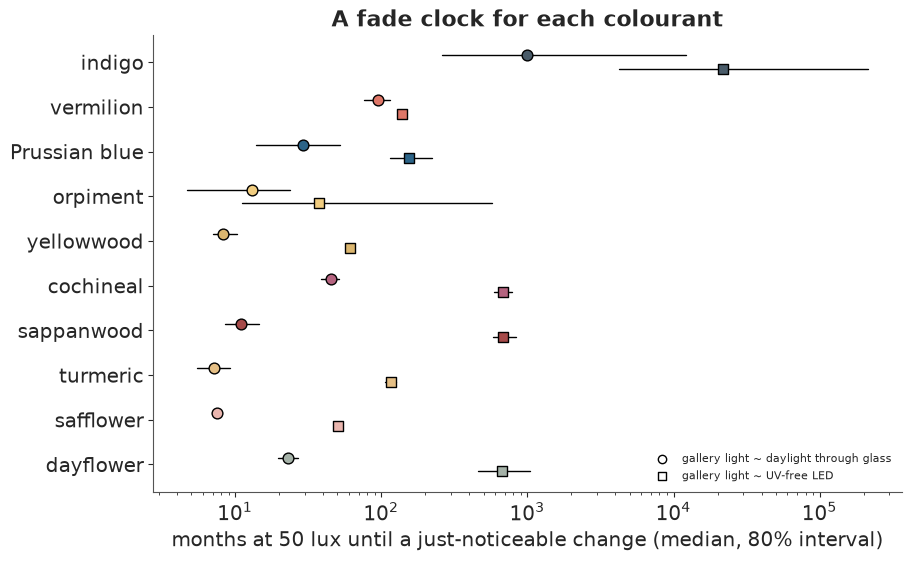

In [34]:
def months_to_jnd(col, n_draws=400, reading="daylight"):
    j = SINGLE.index(col)
    post = az.extract(idata_fade, num_samples=n_draws, random_seed=7)
    k, b = np.exp(post["logk"].values[j]), np.exp(post["logbeta"].values[j])
    inst = "XT" if reading == "daylight" else "MFT"     # which light's degradation products
    rho_, ell_ = post["rho"].sel(inst=inst).values[j], post["ell"].sel(inst=inst).values[j]
    qs = np.concatenate([1 - np.logspace(-5, -0.01, 300)])        # fraction of dye left, descending from 1
    K = (Kp0[None, None] + qs[None, :, None] * EPS[col][None, None]
         + (rho_[:, None] * (1 - qs[None]))[..., None] * np.exp(-(WL - 380) / ell_[:, None])[:, None, :])
    lab = spectra_to_lab(km_reflectance(K))
    de = de2000(spectra_to_lab(km_reflectance(Kp0 + EPS[col])), lab)          # draw x q
    idx = np.argmax(de >= 1, axis=1)
    reached = de[np.arange(n_draws), idx] >= 1
    q_jnd = np.where(reached, qs[idx], np.nan)
    H = (-np.log(q_jnd)) ** (1 / b) / k                                        # xenon-equivalent Mlxh
    if reading == "LED":
        H = H / np.exp(post["logtau"].values[j])
    return H / (50 * 8 * 25 / 1e6)                                             # months at 50 lux


fig, ax = plt.subplots(figsize=(9, 5.5))
rows_g = []
for y, col in enumerate(fugitive + ["Prussian blue", "vermilion", "indigo"]):
    for reading, off, mk in [("daylight", 0.15, "o"), ("LED", -0.15, "s")]:
        mth = months_to_jnd(col, reading=reading)
        ok = mth[np.isfinite(mth)]
        lo, md, hi = np.quantile(ok, [0.1, 0.5, 0.9])
        rgb = lab_to_srgb(spectra_to_lab(km_reflectance(Kp0 + EPS[col])))
        ax.plot([lo, hi], [y + off, y + off], color="k", lw=1)
        ax.scatter(md, y + off, marker=mk, s=60, color=rgb, edgecolor="k", zorder=3)
        rows_g.append((col, reading, lo, md))
ax.set_yticks(range(len(fugitive) + 3))
ax.set_yticklabels(fugitive + ["Prussian blue", "vermilion", "indigo"])
ax.set_xscale("log")
ax.set_xlabel("months at 50 lux until a just-noticeable change (median, 80% interval)")
ax.scatter([], [], marker="o", color="w", edgecolor="k", label="gallery light ~ daylight through glass")
ax.scatter([], [], marker="s", color="w", edgecolor="k", label="gallery light ~ UV-free LED")
ax.legend(fontsize=8, loc="lower right")
ax.set_title("A fade clock for each colourant");

g = pd.DataFrame(rows_g, columns=["colourant", "reading", "risk-based (10% quantile)", "plug-in (median)"])
print(g.pivot(index="colourant", columns="reading").round(1).to_string())

Under the daylight reading, the sensitive colourants reach a just-noticeable change within **7
months to 2 years** at 50 lux (safflower and turmeric first, dayflower last of them); under the LED
reading the same dyes last 5 to 60 times longer. The two readings differ more than the uncertainty
within either, which is the lesson of Part C made practical.

A museum setting a display rule faces two choices, and the posterior makes both explicit:

* **Plug-in vs risk.** The *median* time is the plug-in answer: display that long and there is a
  50% chance the change is already visible. A rule such as "at most a 10% chance of a noticeable
  change" uses the 10% quantile instead: shorter, by a factor that is itself a property of the
  posterior (wider posteriors cost more display time).
* **Which reading of the light.** Until the gallery light itself is characterised against the
  xenon chamber (or the objects are tested under it), a cautious rule takes the daylight reading;
  the LED reading is the optimistic bound.

The same arithmetic applied to a print that is *already* faded gives a different answer: a
dayflower green whose blue is mostly gone has little left to lose, and the next ΔE00 takes longer.
The Part E posterior over how much dye remains is what makes that calculation possible for a real
object.

## Summary

* **A physical model makes colour data go further.** Kubelka-Munk turns "the colour changed" into
  "a fraction $q$ of the dye is left", and the rank check says, before fitting, for which colourants
  that is enough. Browning dyes need a second absorber, and posterior predictive errors plus LOO
  show the fix works.
* **Accelerated tests transfer badly.** A microfading dose is worth between a fiftieth and a
  quarter of a xenon dose depending on the dye, so microfading ranks sensitivities but does not give
  absolute times without an assumption about the light.
* **Running the model backwards is weakly identified, and the posterior says where.** From two
  photographs, the blue of the leaves is dayflower with near certainty, the yellow is unknown, and
  the light dose is known to within a factor of ten or more, because a photograph fixes today's colour
  but not the strength of the new print. Anchors that do not fade (paper, carbon ink) are what make
  photographs comparable, and the restored originals are uncertain by several ΔE00 everywhere: the
  kind of colour, not the exact shade.
* **Discrete choices need the right tool.** A handful of recipes: sum them out inside PyMC. Many
  small multimodal problems (one per colour area): an exact grid posterior per draw.
* **When the estimate is a colour, show colours.** Split swatches, hypothetical restorations and
  trajectory tubes show uncertainty as a spread of colours; a ΔE00 map and bar charts of recipes
  show it in units that leave colour free.

## Try it yourself

1. **The other pair.** The file also holds two impressions of *The Evening Glow of a Lamp*
   (`design == "lamp"`). Register them and draw the residual map. The maple leaves are red in one and
   yellow-green in the other, and the floor is peach in one and green in the other: can any fading
   of any recipe connect them, or is this a different colourway? Add a "same printing" indicator per
   area to the two-impression model and let the posterior decide.
2. **Reciprocity.** Microfading was run at 4.2 Mlx and the chamber at 0.1 Mlx. Replace the free
   transfer factor by $\tau = (E_{\text{MFT}}/E_{\text{XT}})^{p-1}\,u_c$ with a reciprocity exponent
   $p$ shared by all dyes and a UV factor $u_c$. Is $p$ identified with only two intensities? What
   would a third condition have to be to identify it?
3. **Spectral likelihood.** Fit Part B to the reflectance spectra instead of to CIELAB, with a
   Gaussian process over wavelength for the residuals (neighbouring wavelengths err together). Do the
   half-lives change? Which likelihood gives better-calibrated predictions of the xenon colour at
   the last dose when that dose is held out?